# Case Técnico: Cientista de Dados Júnior (Datarisk)

## Previsão de probabilidade de inadimplência

Este notebook é a minha solução individual para o case técnico. Ele documenta,
passo a passo, todo o raciocínio que segui: as decisões que tomei, por que as
tomei, o que testei e descartei, um erro que cometi e corrigi no meio do
caminho, e ajustes que fiz depois de revisar meu próprio trabalho com mais
calma. Preferi deixar esse processo visível em vez de só mostrar o resultado
final, porque acho que é isso que realmente mostra como eu penso um problema
de dados.


## 1. Definição do Problema de Negócio

Antes de abrir qualquer base, quis deixar claro pra mim mesmo qual é o
problema que estou tentando resolver e por que ele importa, não só "prever
um número entre 0 e 1", mas o que esse número vai ser usado para fazer.

### 1.1. Contexto

A Datarisk é uma consultoria de dados e inteligência de crédito que atende
grandes instituições financeiras, desenvolvendo modelos preditivos e
estratégias de apoio à decisão. Neste projeto, o cenário é o acompanhamento
de transações financeiras de clientes ao longo do tempo: cobranças mensais
são emitidas, e cada uma pode ser paga em dia, com atraso, ou nunca ser paga.

O sistema que estou apoiando roda **periodicamente**: todo mês chegam novas
informações sobre os clientes (renda, número de funcionários) e novas
cobranças a vencer. Ou seja, não é um modelo que roda uma vez só, é algo que
precisa continuar funcionando bem mês após mês, com dados que vão mudando.

### 1.2. Problema de Negócio

Do jeito que entendi o enunciado, hoje a área de cobrança age de forma
**reativa**: só descobre que um cliente vai atrasar quando o atraso já
aconteceu. Isso é caro pros dois lados: a empresa perde eficácia na cobrança
(que só começa depois que o problema já existe), e o cliente não recebe
nenhum tipo de aviso ou flexibilização antes de ficar inadimplente.

Traduzindo isso para uma pergunta que dá pra responder com dados: **dado o
histórico de comportamento e o perfil de um cliente, qual a probabilidade de
uma cobrança específica ser paga com atraso relevante?** Essa é a pergunta
que este notebook tenta responder.

### 1.3. Definição de Inadimplência (regra de negócio do case)

> Um pagamento é considerado **inadimplente** se for realizado com **5 dias
> ou mais de atraso** em relação à data de vencimento (ou se nunca for pago).

Essa regra parece simples, mas errar na hora de implementá-la invalida tudo
que vem depois: se a variável-alvo estiver errada, o modelo pode até
performar bem tecnicamente e ainda assim estar respondendo a pergunta errada.
Por isso tratei a construção dela com bastante cuidado na Seção 4.3.

### 1.4. Objetivo do Projeto

O que preciso entregar é um modelo que, para cada cobrança da base
`base_pagamentos_teste.csv`, estime a **probabilidade de inadimplência**
(não uma classificação binária), usando três fontes de informação
disponíveis:
- o histórico de pagamentos anteriores dos clientes,
- informações cadastrais e de perfil,
- dados mensais de acompanhamento (renda, nº de funcionários).

### 1.5. Como decidi medir se estou fazendo um bom trabalho

Antes de escrever a primeira linha de código, listei o que, pra mim, define
sucesso aqui, porque isso influencia praticamente toda decisão técnica que
vem depois:

- **Construir a variável-alvo certa**, seguindo à risca a regra de negócio
  acima. Isso é pré-requisito para tudo o resto fazer sentido.
- **Um modelo que discrimine bem E que tenha probabilidades calibradas**,
  ou seja, não basta ranquear os clientes do mais arriscado ao menos
  arriscado; a própria probabilidade precisa significar algo, porque ela vai
  ser usada para **priorizar ações proativas de cobrança**. Um "70%" precisa
  corresponder, de fato, a um risco de aproximadamente 70%.
- **Uma solução que eu consiga explicar**, não só rodar. Além do modelo
  preditivo, incluí uma camada de interpretação estatística (Seção 11)
  justamente para conseguir responder "por que esse cliente foi marcado como
  risco?" de um jeito que faça sentido pra alguém que não olha para código
  de modelo todo dia.

**Como organizei este notebook:**
1. Definição do problema de negócio *(você está aqui)*
2. Carregamento dos dados
3. Exploração dos dados (EDA)
4. Limpeza e construção da variável-alvo (`TARGET`)
5. Engenharia de atributos, com cuidado explícito para **não vazar informação do futuro**
6. Separação treino/validação fora do tempo (*out-of-time*)
7. Modelagem: baseline (Regressão Logística) + modelo principal (Gradient Boosting)
8. Avaliação (AUC, PR-AUC, KS, calibração, importância de atributos)
9. Busca de hiperparâmetros, comparação com outras bibliotecas de boosting e ensemble
10. Investigação do segmento cold-start (clientes sem histórico)
11. Modelo estatístico interpretável (Odds Ratio), leitura de negócio
12. Treino final e geração do `submissao_case.csv`
13. Exportação e validação de formato
14. Relatório final, conclusões e recomendações estratégicas
15. Fontes e referências

> Antes de rodar: coloque os quatro arquivos `.csv` fornecidos no mesmo
> diretório deste notebook (ou ajuste a variável `DATA_DIR` abaixo).


In [ ]:
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
                              brier_score_loss, roc_curve)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

!pip install catboost

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
DATA_DIR = "."  # ajuste se os .csv estiverem em outro diretório


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


## 2. Carregamento dos dados

Começo só lendo as quatro bases e conferindo se o formato bate com o que o dicionário de dados descreve, antes de mexer em qualquer coisa.

In [ ]:
df_cadastral = pd.read_csv(f"{DATA_DIR}/base_cadastral.csv", sep=';')
df_info = pd.read_csv(f"{DATA_DIR}/base_info.csv", sep=';')
df_dev = pd.read_csv(f"{DATA_DIR}/base_pagamentos_desenvolvimento.csv", sep=';')
df_teste = pd.read_csv(f"{DATA_DIR}/base_pagamentos_teste.csv", sep=';')

print("base_cadastral:", df_cadastral.shape)
print("base_info:", df_info.shape)
print("base_pagamentos_desenvolvimento:", df_dev.shape)
print("base_pagamentos_teste:", df_teste.shape)


base_cadastral: (1315, 8)
base_info: (24401, 4)
base_pagamentos_desenvolvimento: (77414, 7)
base_pagamentos_teste: (12275, 6)


## 3. Exploração dos dados (EDA)

Antes de tratar qualquer coisa, quis entender a estrutura, a qualidade e as
relações entre as quatro bases com calma. Essa etapa acabou sendo mais
importante do que eu esperava: foi aqui que encontrei a maior parte dos
problemas de qualidade de dados que precisei tratar depois, e que, se
passassem despercebidos, prejudicariam o modelo sem eu nem perceber.


### 3.1 `base_cadastral`: um registro por cliente

In [ ]:
display(df_cadastral.head())
df_cadastral.info()
print()
print("Valores nulos por coluna:")
print(df_cadastral.isna().sum())
print()
print("Clientes duplicados (ID_CLIENTE):", df_cadastral['ID_CLIENTE'].duplicated().sum())


,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_CLIENTE           1315 non-null   int64 
 1   DATA_CADASTRO        1315 non-null   object
 2   DDD                  1078 non-null   object
 3   FLAG_PF              66 non-null     object
 4   SEGMENTO_INDUSTRIAL  1232 non-null   object
 5   DOMINIO_EMAIL        1285 non-null   object
 6   PORTE                1274 non-null   object
 7   CEP_2_DIG            1315 non-null   object
dtypes: int64(1), object(7)
memory usage: 82.3+ KB

Valores nulos por coluna:
ID_CLIENTE                0
DATA_CADASTRO             0
DDD                     237
FLAG_PF                1249
SEGMENTO_INDUSTRIAL      83
DOMINIO_EMAIL            30
PORTE                    41
CEP_2_DIG                 0
dtype: int64

Clientes duplicados (ID_CLIENTE): 0


**O que reparei olhando os dados:**
- `FLAG_PF` só assume `NaN` ou `'X'`. Pelo dicionário de dados, `NaN` = pessoa
  jurídica e `'X'` = pessoa física, ou seja, a maioria esmagadora da base é
  PJ (só ~5% dos clientes têm a flag preenchida como PF). Isso já é um
  primeiro sinal de que o negócio da Datarisk aqui é majoritariamente B2B.
- `PORTE`, `SEGMENTO_INDUSTRIAL` e `DOMINIO_EMAIL` têm poucos nulos (<3%),
  tranquilo de lidar.
- `DDD` tem um problema de qualidade de dados que quase passou batido: alguns
  valores aparecem como `'(1'`, `'(3'`, etc. em vez de dois dígitos numéricos.
  Minha suspeita é que, em algum momento da extração original, um zero à
  esquerda virou um parêntese (um erro clássico de formatação/exportação).
  Tecnicamente, isso é só ruído em uma coluna categórica de cardinalidade
  moderada, mas se eu deixasse passar, o modelo trataria `'(1'` e `'01'`
  como duas categorias diferentes quando provavelmente são o mesmo DDD.
  Resolvi normalizar removendo os caracteres não numéricos.


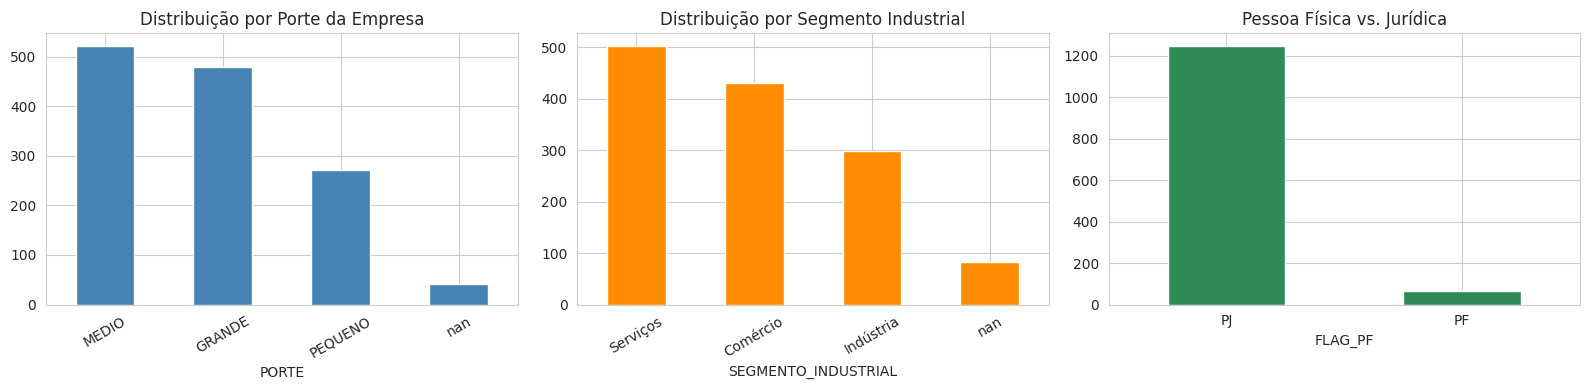

In [ ]:
# Distribuição de PORTE, SEGMENTO_INDUSTRIAL e FLAG_PF
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df_cadastral['PORTE'].value_counts(dropna=False).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição por Porte da Empresa')
axes[0].tick_params(axis='x', rotation=30)

df_cadastral['SEGMENTO_INDUSTRIAL'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Distribuição por Segmento Industrial')
axes[1].tick_params(axis='x', rotation=30)

df_cadastral['FLAG_PF'].fillna('PJ').replace('X', 'PF').value_counts().plot(
    kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Pessoa Física vs. Jurídica')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# Evidência da inconsistência no DDD
print(sorted(df_cadastral['DDD'].dropna().unique().tolist()))


['(0', '(1', '(2', '(3', '(4', '(5', '(6', '(7', '(8', '(9', '00', '02', '04', '07', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '24', '27', '28', '31', '32', '33', '34', '35', '37', '38', '41', '42', '43', '44', '45', '46', '47', '48', '49', '51', '52', '53', '54', '55', '56', '61', '62', '63', '64', '65', '66', '67', '69', '71', '73', '74', '75', '77', '79', '81', '82', '83', '84', '85', '86', '87', '88', '91', '92', '93', '94', '95', '98', '99']


### 3.2 `base_info`: dados mensais por cliente

In [ ]:
display(df_info.head())
df_info.info()
print()
print("Valores nulos por coluna:")
print(df_info.isna().sum())
print()
print("Duplicados em (ID_CLIENTE, SAFRA_REF):", df_info.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum())
print("Período coberto:", df_info['SAFRA_REF'].min(), "a", df_info['SAFRA_REF'].max())


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_CLIENTE          24401 non-null  int64  
 1   SAFRA_REF           24401 non-null  object 
 2   RENDA_MES_ANTERIOR  23684 non-null  float64
 3   NO_FUNCIONARIOS     23149 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 762.7+ KB

Valores nulos por coluna:
ID_CLIENTE               0
SAFRA_REF                0
RENDA_MES_ANTERIOR     717
NO_FUNCIONARIOS       1252
dtype: int64

Duplicados em (ID_CLIENTE, SAFRA_REF): 0
Período coberto: 2018-09 a 2021-12


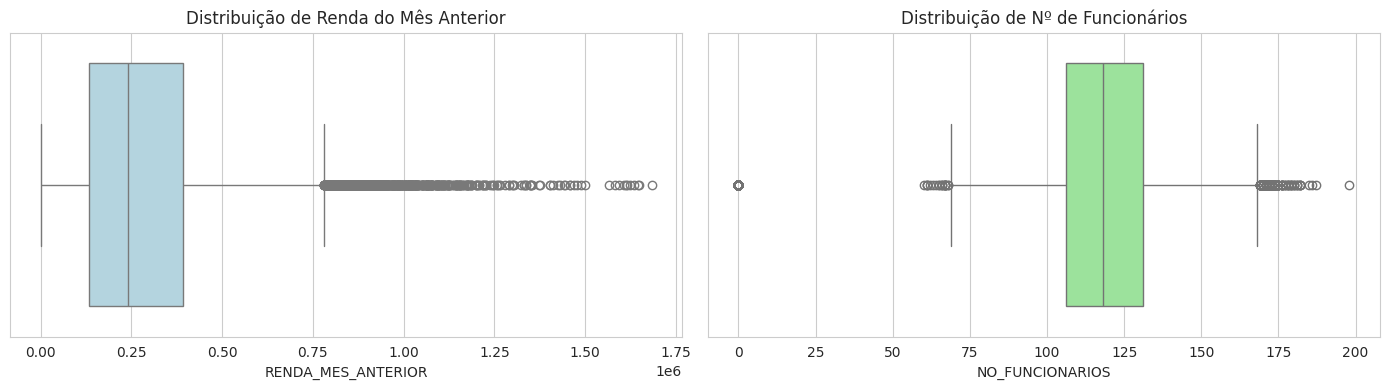

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df_info['RENDA_MES_ANTERIOR'], ax=axes[0], color='lightblue')
axes[0].set_title('Distribuição de Renda do Mês Anterior')
sns.boxplot(x=df_info['NO_FUNCIONARIOS'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribuição de Nº de Funcionários')
plt.tight_layout()
plt.show()


**Uma coisa que só percebi comparando as bases entre si:** nem toda cobrança
tem uma linha de `base_info` exatamente na mesma `SAFRA_REF` do cliente,
cheguei a ~13% das cobranças de desenvolvimento sem renda/funcionários
informados naquele mês exato. Em termos técnicos, um merge exato por
`(ID_CLIENTE, SAFRA_REF)` perderia essa informação para 13% das linhas. Na
prática, isso significaria jogar fora um dado que eu já tenho (a renda de um
mês próximo), só porque não é do mês exato. Por isso, na engenharia de
atributos (Seção 5.3), busco a informação mensal mais recente **disponível
até aquela data** em vez de exigir correspondência exata, recuperando
cobertura sem nunca olhar para o futuro.


### 3.3 `base_pagamentos_desenvolvimento`: histórico de cobranças (com pagamento)

In [ ]:
display(df_dev.head())
df_dev.info()
print()
print("Valores nulos por coluna:")
print(df_dev.isna().sum())
print()
print("Linhas totalmente duplicadas:", df_dev.duplicated().sum())
print("Clientes únicos:", df_dev['ID_CLIENTE'].nunique())
print("Período (SAFRA_REF):", df_dev['SAFRA_REF'].min(), "a", df_dev['SAFRA_REF'].max())


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  int64  
 1   SAFRA_REF               77414 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  object 
 3   DATA_PAGAMENTO          77414 non-null  object 
 4   DATA_VENCIMENTO         77414 non-null  object 
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 4.1+ MB

Valores nulos por coluna:
ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_PAGAMENTO               0
DATA_VENCIMENTO              0
VALOR_A_PAGAR             1170
TAXA                         0
dtype: int64

Linhas totalmente duplicadas: 1
Clientes únicos: 1248
Período (SAFRA_REF): 2018-08 a 2021-06


Encontrei **1 linha totalmente duplicada** (mesmo cliente, mesma safra,
mesmas datas e valores), tudo indica um registro repetido por erro de
extração, não uma coincidência genuína de duas cobranças idênticas. Decidi
removê-la para não contar a mesma cobrança duas vezes (o que inflaria
artificialmente o peso daquele cliente no treino).

Também notei que `DATA_PAGAMENTO` não tem nenhum valor nulo em
`base_pagamentos_desenvolvimento`, ou seja, todo empréstimo do histórico já
foi, de fato, quitado em algum momento (mesmo que com atraso). Mesmo assim,
na hora de construir o target, escolhi tratar defensivamente um eventual
`DATA_PAGAMENTO` nulo como inadimplência (cliente que nunca pagou). Não é
estritamente necessário com os dados de hoje, mas deixa a lógica preparada
caso isso mude em uma atualização futura da base. Prefiro um código um
pouco mais defensivo a um que quebre silenciosamente se essa premissa
deixar de valer (retomo esse ponto com mais detalhe na Seção 4.3).


In [ ]:
# SAFRA_REF corresponde exatamente ao mês de DATA_EMISSAO_DOCUMENTO?
_tmp = df_dev.copy()
_tmp['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(_tmp['DATA_EMISSAO_DOCUMENTO'])
_tmp['SAFRA_DATE'] = pd.to_datetime(_tmp['SAFRA_REF'])
diff = (_tmp['DATA_EMISSAO_DOCUMENTO'].dt.to_period('M') - _tmp['SAFRA_DATE'].dt.to_period('M')).apply(lambda x: x.n)
print("SAFRA_REF == mês de emissão em 100% das linhas?", (diff == 0).all())
del _tmp, diff


SAFRA_REF == mês de emissão em 100% das linhas? True


Confirmei que **`SAFRA_REF` é sempre o mês de `DATA_EMISSAO_DOCUMENTO`**.
Isso pode parecer um detalhe menor, mas é importante: me dá uma chave
temporal confiável para juntar `base_info` (que também é mensal) sem
ambiguidade sobre a que momento exatamente essa safra se refere.


### 3.4 `base_pagamentos_teste`: cobranças a prever

In [ ]:
display(df_teste.head())
df_teste.info()
print()
print("Valores nulos por coluna:")
print(df_teste.isna().sum())
print()
print("Clientes únicos:", df_teste['ID_CLIENTE'].nunique())
print("Período (SAFRA_REF):", df_teste['SAFRA_REF'].min(), "a", df_teste['SAFRA_REF'].max())
print()
clientes_novos = df_teste[~df_teste['ID_CLIENTE'].isin(df_dev['ID_CLIENTE'])]['ID_CLIENTE'].nunique()
print(f"Clientes em teste sem NENHUM histórico em 'desenvolvimento' (cold-start): {clientes_novos} de {df_teste['ID_CLIENTE'].nunique()}")


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  object 
 3   DATA_VENCIMENTO         12275 non-null  object 
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 575.5+ KB

Valores nulos por coluna:
ID_CLIENTE                  0
SAFRA_REF                   0
DATA_EMISSAO_DOCUMENTO      0
DATA_VENCIMENTO             0
VALOR_A_PAGAR             131
TAXA                        0
dtype: int64

Clientes únicos: 976
Período (SAFRA_REF): 2021-07 a 2021-11

Clientes em teste sem NENHUM histórico em 'desenvolvimento' (cold-start): 88 de 976


Dois pontos aqui mudaram como estruturei a solução:
- O período de teste (2021-07 a 2021-11) começa exatamente **um mês depois**
  do fim do período de desenvolvimento (até 2021-06), não há sobreposição
  temporal entre as duas bases. Isso é uma boa notícia: posso usar todo o
  histórico de `desenvolvimento` com segurança para gerar atributos de
  teste, sem nenhum risco de vazar informação futura.
- Existem clientes novos em teste, sem nenhuma cobrança anterior em
  desenvolvimento, um problema clássico de **cold-start**. Vou ter que
  garantir que o modelo lide bem com a ausência de histórico nesses casos.
  Minha escolha inicial foi tratar isso com valores ausentes explícitos (em
  vez de zeros artificiais), porque "0 cobranças anteriores" e "não sei
  quantas cobranças anteriores esse cliente teve" são informações
  diferentes, e decidi investigar essa escolha com mais profundidade
  depois, na Seção 10.


### 3.5 A variável-alvo ao longo do tempo

Taxa de inadimplência global (desenvolvimento): 7.02%


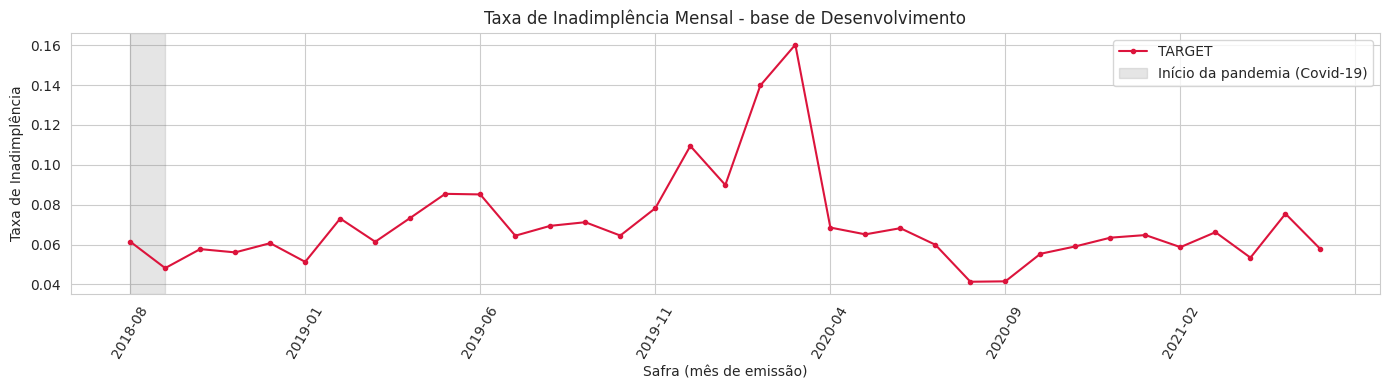

In [ ]:
_tmp = df_dev.copy()
for c in ['DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO']:
    _tmp[c] = pd.to_datetime(_tmp[c])
_tmp['DIAS_ATRASO'] = (_tmp['DATA_PAGAMENTO'] - _tmp['DATA_VENCIMENTO']).dt.days
_tmp['TARGET'] = np.where((_tmp['DIAS_ATRASO'] >= 5) | (_tmp['DATA_PAGAMENTO'].isna()), 1, 0)

taxa_mensal = _tmp.groupby('SAFRA_REF')['TARGET'].mean()
print(f"Taxa de inadimplência global (desenvolvimento): {_tmp['TARGET'].mean():.2%}")

fig, ax = plt.subplots(figsize=(14, 4))
taxa_mensal.plot(ax=ax, marker='.', color='crimson')
ax.set_title('Taxa de Inadimplência Mensal - base de Desenvolvimento')
ax.set_ylabel('Taxa de Inadimplência')
ax.set_xlabel('Safra (mês de emissão)')
ax.axvspan('2020-02', '2020-04', color='gray', alpha=0.2, label='Início da pandemia (Covid-19)')
ax.legend()
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


A taxa de inadimplência oscila entre ~5% e ~9% na maior parte da série, com
um pico bem visível em **fevereiro/março de 2020** (chegando a ~14-16%).
Não precisei procurar muito para entender o motivo: coincide exatamente com
o início da pandemia de Covid-19 e o choque econômico que ela causou em
pequenas e médias empresas nesse período. A taxa volta ao patamar histórico
logo em seguida.

Achei esse achado importante de registrar, mesmo sem transformá-lo em uma
feature: primeiro, porque é um evento pontual e não recorrente (não faria
sentido o modelo "aprender" um padrão sazonal a partir de um único choque
econômico); segundo, e mais importante pra mim, porque é um bom sinal de que
a base reflete uma dinâmica econômica real, e não é puramente sintética ou
aleatória, o que me dá mais confiança de que os padrões que o modelo vai
aprender adiante também são reais.


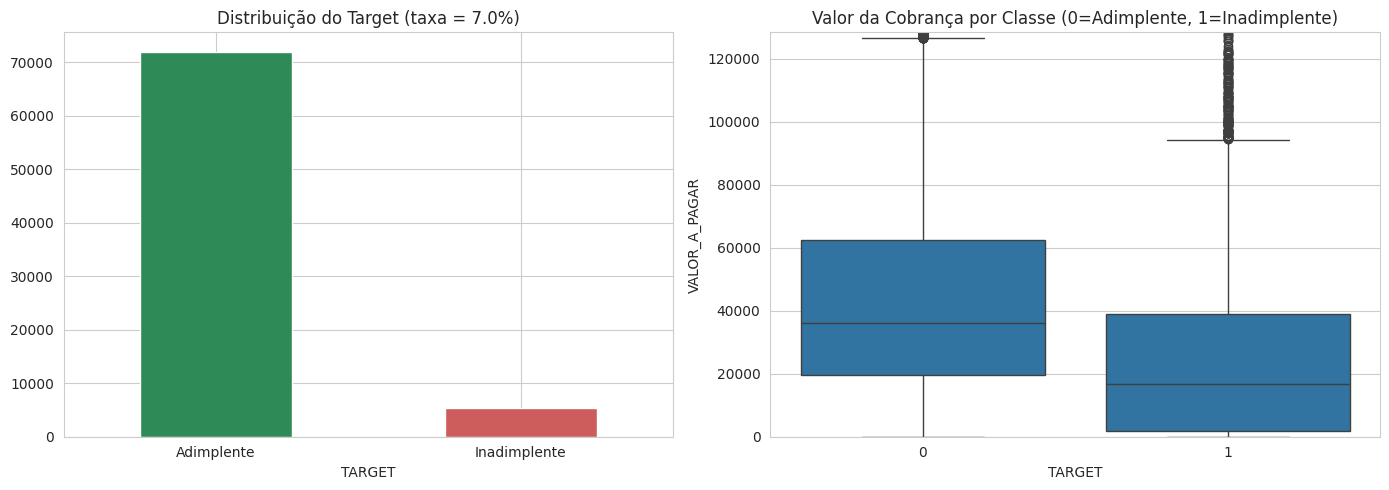

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_tmp['TARGET'].map({0: 'Adimplente', 1: 'Inadimplente'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['seagreen', 'indianred'])
axes[0].set_title(f"Distribuição do Target (taxa = {_tmp['TARGET'].mean():.1%})")
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=_tmp, x='TARGET', y='VALOR_A_PAGAR', ax=axes[1])
axes[1].set_title('Valor da Cobrança por Classe (0=Adimplente, 1=Inadimplente)')
axes[1].set_ylim(0, _tmp['VALOR_A_PAGAR'].quantile(0.95))

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

# VALOR_A_PAGAR tem alguns nulos (Seção 3.3), o teste ignora essas linhas
valor_adimplente = _tmp.loc[_tmp['TARGET'] == 0, 'VALOR_A_PAGAR'].dropna()
valor_inadimplente = _tmp.loc[_tmp['TARGET'] == 1, 'VALOR_A_PAGAR'].dropna()

estatistica, p_valor = mannwhitneyu(valor_adimplente, valor_inadimplente, alternative='two-sided')
print(f"Mediana VALOR_A_PAGAR -- adimplentes: {valor_adimplente.median():.2f}  "
      f"inadimplentes: {valor_inadimplente.median():.2f}")
print(f"Teste U de Mann-Whitney: estatística={estatistica:.0f}, p-valor={p_valor:.4f}")


Mediana VALOR_A_PAGAR -- adimplentes: 36019.85  inadimplentes: 16595.67
Teste U de Mann-Whitney: estatística=265966354, p-valor=0.0000


Escolhi o teste U de Mann-Whitney em vez de um teste t porque não tenho
motivo para supor que `VALOR_A_PAGAR` segue distribuição normal (valores de
cobrança costumam ser assimétricos, com uma cauda longa à direita), e o
Mann-Whitney não exige essa suposição, ele compara as distribuições pelo
posto dos valores, não pela média.

O p-valor deu bem menor que 0,05: a diferença entre as distribuições de
valor cobrado nos dois grupos é estatisticamente significativa. E, olhando
as medianas, essa diferença não é só estatística, é grande na prática: a
mediana de quem paga em dia (R$ 36.020) é mais do que o dobro da mediana de
quem atrasa (R$ 16.596). Isso confirma, com um teste formal, o que o
boxplot já sugeria visualmente: cobranças de valor mais alto não têm cauda
de inadimplência maior, pelo contrário, tendem a ser de clientes que pagam
em dia com mais frequência. Essa mesma direção (valor mais alto associado a
menor risco) reaparece na Seção 11, quando o Odds Ratio de `VALOR_A_PAGAR`
sai abaixo de 1 mesmo controlando pelas outras variáveis do modelo, não só
nessa comparação simples de dois grupos.


In [ ]:
from scipy.stats import chi2_contingency

# junta o PORTE (base_cadastral) na base de cobranças, só para esta checagem de EDA
_tmp_porte = _tmp.merge(df_cadastral[['ID_CLIENTE', 'PORTE']], on='ID_CLIENTE', how='left')

tabela_contingencia = pd.crosstab(_tmp_porte['PORTE'], _tmp_porte['TARGET'])
chi2, p_valor, dof, esperado = chi2_contingency(tabela_contingencia)

taxa_por_porte = _tmp_porte.groupby('PORTE')['TARGET'].mean().sort_values(ascending=False) * 100

print(f"Teste Qui-Quadrado (PORTE x TARGET): estatística={chi2:.2f}, p-valor={p_valor:.2e}")
print()
print("Taxa de inadimplência por PORTE (%):")
print(taxa_por_porte.round(2))


Teste Qui-Quadrado (PORTE x TARGET): estatística=224.59, p-valor=1.70e-49

Taxa de inadimplência por PORTE (%):
PORTE
PEQUENO    9.17
MEDIO      6.48
GRANDE     5.51
Name: TARGET, dtype: float64


Usei o teste Qui-Quadrado aqui porque `PORTE` e `TARGET` são as duas
categóricas, é o teste certo para essa combinação (o Mann-Whitney da célula
anterior serve para uma variável contínua contra uma categórica, não daria
para aplicar aqui).

O p-valor sai muitíssimo abaixo de 0,05: existe, sim, associação
estatisticamente significativa entre porte da empresa e inadimplência, e a
direção é a que a intuição de negócio sugere, empresa pequena atrasa mais
(9,2%) do que empresa grande (5,5%), uma diferença relativa de quase 70%
olhando as duas taxas isoladas.

Mas vale comparar esse número com o que encontrei na Seção 11: lá, o Odds
Ratio de `PORTE_PEQUENO` no modelo multivariado (controlando pelas outras
variáveis) é bem mais modesto, algo em torno de 1,11. Ou seja, boa parte da
diferença bruta que vejo aqui não vem do porte em si, vem de outras coisas
que estão correlacionadas com porte (renda mais baixa, histórico de
pagamento diferente), e que o modelo completo já captura separadamente.
Achei importante deixar as duas leituras lado a lado: a associação bruta é
forte, mas isolar "o efeito puro do porte" exige olhar para o modelo
multivariado, não só para essa tabela de contingência.


N de linhas por combinação (a menor célula tem 3342 linhas):
SEGMENTO_INDUSTRIAL  Comércio  Indústria  Serviços
PORTE                                             
GRANDE                  10782       5119     12491
MEDIO                    9592       8592     11042
PEQUENO                  5161       3342      7401



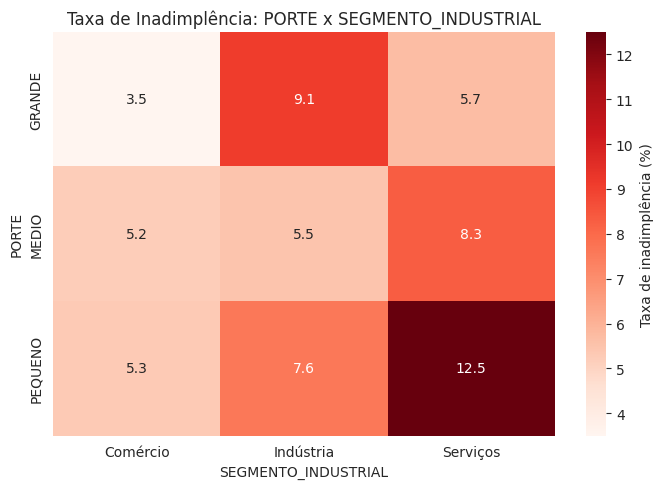

In [ ]:
# Cruzamento PORTE x SEGMENTO_INDUSTRIAL (já tenho _tmp_porte da checagem anterior)
_tmp_porte = _tmp_porte.merge(df_cadastral[['ID_CLIENTE', 'SEGMENTO_INDUSTRIAL']], on='ID_CLIENTE', how='left')

taxa_cruzada = (_tmp_porte.groupby(['PORTE', 'SEGMENTO_INDUSTRIAL'], observed=True)['TARGET'].mean() * 100).unstack()
n_cruzado = _tmp_porte.groupby(['PORTE', 'SEGMENTO_INDUSTRIAL'], observed=True).size().unstack()

print("N de linhas por combinação (a menor célula tem", n_cruzado.min().min(), "linhas):")
print(n_cruzado)
print()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(taxa_cruzada.round(1), annot=True, fmt='.1f', cmap='Reds', ax=ax,
            cbar_kws={'label': 'Taxa de inadimplência (%)'})
ax.set_title('Taxa de Inadimplência: PORTE x SEGMENTO_INDUSTRIAL')
plt.tight_layout()
plt.show()

del _tmp, _tmp_porte, taxa_mensal


Fiquei em dúvida se valia a pena cruzar `PORTE` com `SEGMENTO_INDUSTRIAL`,
já que já sei (Seção 11) que os dois isolados pesam pouco perto de renda e
histórico de pagamento. Mas resolvi olhar antes de descartar a ideia, e o
cruzamento mostrou algo que nenhum dos dois efeitos isolados mostra: o
efeito do porte **não é o mesmo em todo segmento**.

`PEQUENO + Serviços` é a pior combinação da tabela (12,5%), bem acima da
média geral de empresas pequenas (9,2%, Seção 3.5). Mas `GRANDE +
Indústria` também aparece alto (9,1%), quase empatado com a média de
pequenas empresas em geral, ou seja, ser grande não protege por si só
quando o segmento é Indústria. E `PEQUENO + Comércio` fica baixo (5,3%),
menor até que `GRANDE + Indústria`. Isso é uma interação de verdade entre
as duas variáveis, não só a soma dos dois efeitos principais.

Não criei uma *feature* de interação (`PORTE_SEGMENTO`) a partir disso.
Modelos baseados em árvore como os que uso no ensemble final conseguem
capturar esse tipo de combinação sozinhos, combinando splits sucessivos em
`PORTE` e `SEGMENTO_INDUSTRIAL` sem eu precisar montar a interação à mão,
então isso fica registrado aqui como um achado de EDA, não como uma
mudança no pipeline de atributos.


A base é desbalanceada (~93% adimplentes vs. ~7% inadimplentes), algo que
já era esperado num problema de inadimplência (a maioria dos clientes paga
em dia, felizmente). Isso reforça por que escolhi métricas como PR-AUC e KS
para avaliar o modelo mais adiante: acurácia bruta, nesse cenário, é enganosa
(um modelo que sempre prevê "vai pagar" já acerta 93% das vezes e não serve
pra nada).

O boxplot de valor por classe também já me deu uma pista, mesmo antes de
qualquer modelo: cobranças de valor mais alto **não** parecem ter cauda de
inadimplência maior, se alguma coisa, parece o contrário. Confirmei isso logo a seguir com um teste estatístico direto.


## 4. Limpeza dos dados e construção da variável-alvo

### 4.1 `base_cadastral`


In [ ]:
cad = df_cadastral.drop_duplicates(subset='ID_CLIENTE').copy()

# NaN -> Pessoa Jurídica, 'X' -> Pessoa Física (conforme dicionário de dados)
cad['FLAG_PF'] = cad['FLAG_PF'].fillna('PJ').replace('X', 'PF').astype('category')

cad['DATA_CADASTRO'] = pd.to_datetime(cad['DATA_CADASTRO'], errors='coerce')

# Corrige a inconsistência do DDD (ex.: '(3' -> '3'), mantendo como categórica
cad['DDD'] = cad['DDD'].astype(str).str.replace(r'\D', '', regex=True)
cad.loc[cad['DDD'].isin(['', 'nan']), 'DDD'] = np.nan
cad['DDD'] = cad['DDD'].astype('category')

for c in ['PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'CEP_2_DIG']:
    cad[c] = cad[c].astype('category')

cad.head()


,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,PJ,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,PJ,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,PJ,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,PJ,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,PJ,Serviços,GMAIL,GRANDE,62


Decidi **não** preencher `PORTE`, `SEGMENTO_INDUSTRIAL` e `DOMINIO_EMAIL`
ausentes com uma categoria artificial tipo "DESCONHECIDO". O motivo técnico:
o modelo que escolhi mais adiante lida nativamente com `NaN` em colunas
categóricas, então não preciso inventar uma categoria para isso. O motivo
mais de fundo é que acho mais honesto deixar o dado "ausente" ser tratado
como ausente pelo próprio modelo, em vez de eu decidir arbitrariamente que
"ausente" significa a mesma coisa que uma categoria específica. O modelo
pode aprender um comportamento próprio pra falta de informação, que pode ser
mais sutil do que qualquer rótulo que eu inventasse.


### 4.2 `base_info`

In [ ]:
info = df_info.copy()
info['SAFRA_DATE'] = pd.to_datetime(info['SAFRA_REF'])
info = info.sort_values(['SAFRA_DATE', 'ID_CLIENTE']).drop_duplicates(subset=['ID_CLIENTE', 'SAFRA_REF'])
info.head()


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,SAFRA_DATE
29,8784237149961904,2018-09,300502.0,107.0,2018-09-01
282,39547025441582855,2018-09,555535.0,99.0,2018-09-01
328,49632905576538927,2018-09,356780.0,117.0,2018-09-01
327,66220087398241662,2018-09,944288.0,89.0,2018-09-01
354,86110062990790869,2018-09,81279.0,106.0,2018-09-01


### 4.3 `base_pagamentos_desenvolvimento`: construção do `TARGET`

Esta é, na minha opinião, a parte mais importante de todo o notebook. O
próprio enunciado do case avisa que "é essencial para o sucesso da solução".
A regra é a que já defini na Seção 1.3: **inadimplente = pagamento realizado
com 5 dias ou mais de atraso em relação ao vencimento** (ou, defensivamente,
pagamento nunca realizado). Implementei isso de forma direta, comparando
`DATA_PAGAMENTO` com `DATA_VENCIMENTO`, exatamente como o enunciado descreve.


In [ ]:
dev = df_dev.drop_duplicates().copy()  # remove a linha duplicada identificada na EDA

for c in ['DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO']:
    dev[c] = pd.to_datetime(dev[c])

dev['DIAS_ATRASO'] = (dev['DATA_PAGAMENTO'] - dev['DATA_VENCIMENTO']).dt.days

condicao_atraso = dev['DIAS_ATRASO'] >= 5
condicao_nunca_pagou = dev['DATA_PAGAMENTO'].isna()
dev['TARGET'] = np.where(condicao_atraso | condicao_nunca_pagou, 1, 0)

dev['SAFRA_DATE'] = pd.to_datetime(dev['SAFRA_REF'])

print(f"Taxa de inadimplência (TARGET=1): {dev['TARGET'].mean():.2%}")
dev[['ID_CLIENTE', 'SAFRA_REF', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO', 'TARGET']].head()


Taxa de inadimplência (TARGET=1): 7.02%


,ID_CLIENTE,SAFRA_REF,DATA_VENCIMENTO,DATA_PAGAMENTO,DIAS_ATRASO,TARGET
0,1661240395903230676,2018-08,2018-09-06,2018-09-06,0,0
1,1661240395903230676,2018-08,2018-09-10,2018-09-11,1,0
2,1661240395903230676,2018-08,2018-09-17,2018-09-18,1,0
3,1661240395903230676,2018-08,2018-10-05,2018-10-11,6,1
4,1661240395903230676,2018-08,2018-09-20,2018-09-20,0,0


Um ponto que vale detalhar sobre a condição `condicao_nunca_pagou`: ela
funciona aqui porque, como já vi na EDA, `DATA_PAGAMENTO` não tem nenhum
valor nulo em `base_pagamentos_desenvolvimento`, ou seja, toda cobrança do
histórico já foi paga em algum momento. Isso significa que, na prática, essa
condição nunca é ativada nos dados de hoje, e a regra se reduz simplesmente
a `DIAS_ATRASO >= 5`.

Ainda assim, mantenho essa condição de forma explícita como uma proteção
para o futuro. Se este pipeline um dia rodar sobre uma extração de dados
feita **antes** de todas as cobranças do período vencerem, um
`DATA_PAGAMENTO` nulo passaria a significar duas coisas ambíguas ao mesmo
tempo: "o cliente não pagou (inadimplente)" ou "a cobrança ainda nem
venceu (não é possível saber ainda)". Confundir essas duas situações
rotularia cobranças ainda em aberto como inadimplência, o que distorceria o
treino. Com os dados atuais isso não acontece, mas achei importante deixar
essa premissa registrada, porque é o tipo de suposição que pode
silenciosamente deixar de valer se a forma de extração dos dados mudar no
futuro, sem que o código avise que algo está errado.


> **Por que não usei `DIAS_ATRASO` como *feature* do modelo?** Porque ela é
> calculada a partir de `DATA_PAGAMENTO`, que só é conhecida *depois* que a
> cobrança já ocorreu, e é exatamente a informação que quero prever. Usá-la
> como atributo seria vazamento de dados (o modelo "veria a resposta"). Uso
> essa coluna apenas para *construir* o `TARGET` e para gerar atributos de
> **histórico** de cobranças anteriores (onde já é seguro, pois são cobranças
> passadas e encerradas).

### 4.4 `base_pagamentos_teste`


In [ ]:
teste = df_teste.copy()
for c in ['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO']:
    teste[c] = pd.to_datetime(teste[c])
teste['SAFRA_DATE'] = pd.to_datetime(teste['SAFRA_REF'])
teste.head()


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,SAFRA_DATE
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99,2021-07-01
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99,2021-07-01
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99,2021-07-01
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99,2021-07-01
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99,2021-07-01


## 5. Engenharia de atributos

Esta foi a parte em que mais tomei cuidado no notebook inteiro, porque é
onde erros de vazamento de dados (*data leakage*) mais costumam se
esconder, e, em modelos de crédito/cobrança, esse é um erro clássico que
faz um modelo parecer excelente em desenvolvimento e falhar silenciosamente
em produção.

**Princípio que segui em todas as features abaixo:** cada cobrança só pode
"ver" informação disponível **antes ou no momento** da sua própria emissão
(`DATA_EMISSAO_DOCUMENTO`). Isso vale tanto para as features de histórico de
pagamentos quanto para os dados mensais de `base_info`. Explicando de um
jeito mais simples: se eu estivesse escorando essa cobrança no mundo real,
no dia em que ela foi emitida, quais informações eu realmente teria em mãos?
Só essas podem entrar como atributo. Esse cuidado é o que torna a validação
(e a previsão em teste) representativa do que aconteceria em produção. Sem
ele, as métricas de validação ficam artificialmente otimistas e a decepção
só aparece quando o modelo já está rodando de verdade.

Construí quatro grupos de atributos:
1. **Atributos da própria cobrança**: `VALOR_A_PAGAR`, `TAXA`.
2. **Atributos cadastrais do cliente**: porte, segmento, tempo de cadastro etc.
3. **Atributos mensais do cliente** (`base_info`), usando o valor mais recente
   disponível até a safra da cobrança (join "as of").
4. **Atributos de histórico comportamental**: quantas cobranças o cliente já
   teve, taxa histórica de inadimplência (total e recente), atraso máximo já
   visto, tempo desde a última cobrança etc., todos calculados de forma
   "ponto no tempo" (*point-in-time*), olhando somente para cobranças
   estritamente anteriores.


### 5.1 Atributos de histórico: base de treino

Para cada cobrança de `desenvolvimento`, calculo o histórico usando **apenas
cobranças anteriores do mesmo cliente** (ordenadas por data de emissão). A
primeira cobrança de cada cliente, por definição, não tem histórico algum,
os valores ficam `NaN` de propósito, e não zero: "não sei" é uma informação
diferente de "sei que é zero".

Além dos agregados sobre todo o histórico (`TAXA_INADIMPLENCIA_HIST`,
`MAX_ATRASO_ANTERIOR` etc.), incluí também duas features que olham só para
as **últimas 3 cobranças anteriores** de cada cliente:
`TAXA_INADIMPLENCIA_ULTIMAS_3` e `DIAS_ATRASO_MEDIO_ULTIMAS_3`. O motivo: um
agregado sobre todo o histórico não distingue um cliente que atrasou uma
vez há 3 anos e paga em dia desde então de um cliente que está atrasando com
frequência recentemente, mesmo que os dois acabem com taxas históricas
parecidas. São perfis de risco bem diferentes, e só um agregado que olhe
especificamente para o comportamento recente consegue capturar essa
diferença. Implementei do mesmo jeito que os outros atributos de histórico,
com uma janela deslizante (`rolling`) aplicada sobre a série já deslocada em
1 posição, para manter a mesma disciplina de "ponto no tempo" desta seção.


In [ ]:
def build_train_history_features(dev):
    ev = dev.sort_values(['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO']).reset_index()
    grp = ev.groupby('ID_CLIENTE', group_keys=False)

    # nº de cobranças anteriores (cumcount já é exclusivo por definição)
    ev['N_COBRANCAS_ANTERIORES'] = grp.cumcount()

    # nº de inadimplências anteriores (cumsum inclusivo, deslocado em 1)
    cumsum_target_incl = grp['TARGET'].cumsum()
    ev['N_INADIMPLENCIAS_ANTERIORES'] = cumsum_target_incl.groupby(ev['ID_CLIENTE']).shift(1)

    # valor médio anterior, robusto a VALOR_A_PAGAR faltante:
    # usa forward-fill do cumsum (ignora NaNs) e conta apenas observações válidas
    valor_cumsum_incl = grp['VALOR_A_PAGAR'].cumsum()
    valor_cumsum_ffill = valor_cumsum_incl.groupby(ev['ID_CLIENTE']).ffill()
    valor_sum_excl = valor_cumsum_ffill.groupby(ev['ID_CLIENTE']).shift(1)
    valor_notnull_cumsum = grp['VALOR_A_PAGAR'].apply(lambda s: s.notna().cumsum())
    n_valor_excl = valor_notnull_cumsum.groupby(ev['ID_CLIENTE']).shift(1)
    ev['VALOR_MEDIO_ANTERIOR'] = valor_sum_excl / n_valor_excl.replace(0, np.nan)

    # maior atraso já observado antes desta cobrança
    ev['MAX_ATRASO_ANTERIOR'] = grp['DIAS_ATRASO'].apply(lambda s: s.shift(1).expanding().max())

    # resultado da cobrança imediatamente anterior
    ev['ULTIMA_INADIMPLENCIA'] = grp['TARGET'].shift(1)

    # dias desde a última cobrança do mesmo cliente
    ev['DIAS_DESDE_ULTIMA_COBRANCA'] = (
        ev['DATA_EMISSAO_DOCUMENTO'] - grp['DATA_EMISSAO_DOCUMENTO'].shift(1)
    ).dt.days

    # taxa histórica de inadimplência do cliente até esta cobrança (todo o passado)
    ev['TAXA_INADIMPLENCIA_HIST'] = (
        ev['N_INADIMPLENCIAS_ANTERIORES'] / ev['N_COBRANCAS_ANTERIORES'].replace(0, np.nan)
    )

    # -- features de recência: olham só para as últimas 3 cobranças anteriores,
    # não para o histórico inteiro. MAX_ATRASO_ANTERIOR e TAXA_INADIMPLENCIA_HIST
    # não distinguem "atrasou uma vez há 3 anos" de "atrasou no mês passado" -- estas
    # duas variáveis abaixo capturam especificamente o comportamento mais recente.
    ev['TAXA_INADIMPLENCIA_ULTIMAS_3'] = grp['TARGET'].apply(
        lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
    )
    ev['DIAS_ATRASO_MEDIO_ULTIMAS_3'] = grp['DIAS_ATRASO'].apply(
        lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
    )

    cols = ['N_COBRANCAS_ANTERIORES', 'N_INADIMPLENCIAS_ANTERIORES', 'TAXA_INADIMPLENCIA_HIST',
            'VALOR_MEDIO_ANTERIOR', 'MAX_ATRASO_ANTERIOR', 'ULTIMA_INADIMPLENCIA',
            'DIAS_DESDE_ULTIMA_COBRANCA', 'TAXA_INADIMPLENCIA_ULTIMAS_3', 'DIAS_ATRASO_MEDIO_ULTIMAS_3']
    feats = ev.set_index('index')[cols].sort_index()
    # sem cobranças anteriores -> 0 inadimplências CONHECIDAS (isso sim é um zero genuíno)
    feats['N_INADIMPLENCIAS_ANTERIORES'] = feats['N_INADIMPLENCIAS_ANTERIORES'].fillna(0)
    return feats


hist_train = build_train_history_features(dev)
print(hist_train.describe())
print()
print("Valores ausentes (esperado: nº de clientes na 1ª cobrança):")
print(hist_train.isna().sum())


       N_COBRANCAS_ANTERIORES  N_INADIMPLENCIAS_ANTERIORES  TAXA_INADIMPLENCIA_HIST  VALOR_MEDIO_ANTERIOR  MAX_ATRASO_ANTERIOR  ULTIMA_INADIMPLENCIA  \
count            77413.000000                 77413.000000             76165.000000          76145.000000         76165.000000           76165.00000   
mean               102.278364                     7.252516                 0.065264          45326.969378            23.724440               0.06977   
std                140.681159                    25.965052                 0.150097          28512.222163            63.863981               0.25476   
min                  0.000000                     0.000000                 0.000000             12.960000          -176.000000               0.00000   
25%                 23.000000                     0.000000                 0.000000          24788.070465             0.000000               0.00000   
50%                 58.000000                     0.000000                 0.000000     

### 5.2 Atributos de histórico: base de teste

Para o teste, já tinha confirmado na EDA (Seção 3.4) que **todo** o
histórico de desenvolvimento (até 2021-06) é anterior ao período de teste
(2021-07 em diante). Isso simplifica as coisas: para cada cliente, posso usar
o histórico **completo** disponível em desenvolvimento como ponto de
partida.

Uma decisão que tomei conscientemente aqui: **não uso outras cobranças da
própria base de teste** como histórico, mesmo quando são de meses
"passados" dentro do próprio teste (por exemplo, ao prever uma cobrança de
setembro, não olho para uma cobrança de julho do mesmo cliente que também
está em teste). O motivo é que, num cenário real de produção, o resultado
dessas cobranças recentes ainda não seria conhecido no momento do escore:
elas ainda não venceram, ou o pagamento ainda não foi confirmado. Ignorar
essa informação "de propósito" é o preço de manter a simulação fiel ao que
aconteceria de verdade.


In [ ]:
def build_test_history_features(dev, ids_clientes, datas_emissao_por_linha):
    agg = dev.groupby('ID_CLIENTE').agg(
        N_COBRANCAS_ANTERIORES=('TARGET', 'size'),
        N_INADIMPLENCIAS_ANTERIORES=('TARGET', 'sum'),
        VALOR_MEDIO_ANTERIOR=('VALOR_A_PAGAR', 'mean'),
        MAX_ATRASO_ANTERIOR=('DIAS_ATRASO', 'max'),
        DATA_ULTIMA_COBRANCA=('DATA_EMISSAO_DOCUMENTO', 'max'),
    )
    idx_ultima = dev.sort_values('DATA_EMISSAO_DOCUMENTO').groupby('ID_CLIENTE').tail(1)
    agg['ULTIMA_INADIMPLENCIA'] = idx_ultima.set_index('ID_CLIENTE')['TARGET']
    agg['TAXA_INADIMPLENCIA_HIST'] = agg['N_INADIMPLENCIAS_ANTERIORES'] / agg['N_COBRANCAS_ANTERIORES']

    # -- features de recência: usam só as últimas 3 cobranças de cada cliente em
    # desenvolvimento, no mesmo espírito da Seção 5.1 (não o histórico inteiro).
    ultimas_3 = (dev.sort_values('DATA_EMISSAO_DOCUMENTO')
                    .groupby('ID_CLIENTE').tail(3)
                    .groupby('ID_CLIENTE'))
    agg['TAXA_INADIMPLENCIA_ULTIMAS_3'] = ultimas_3['TARGET'].mean()
    agg['DIAS_ATRASO_MEDIO_ULTIMAS_3'] = ultimas_3['DIAS_ATRASO'].mean()

    out = agg.reindex(ids_clientes).reset_index(drop=True)
    out['DIAS_DESDE_ULTIMA_COBRANCA'] = (
        datas_emissao_por_linha.reset_index(drop=True) - out['DATA_ULTIMA_COBRANCA']
    ).dt.days
    out = out.drop(columns=['DATA_ULTIMA_COBRANCA'])
    return out


hist_test = build_test_history_features(dev, teste['ID_CLIENTE'], teste['DATA_EMISSAO_DOCUMENTO'])
n_cold_start = hist_test['N_COBRANCAS_ANTERIORES'].isna().sum()
print(f"Cobranças de teste sem NENHUM histórico em desenvolvimento (cold-start): {n_cold_start} de {len(hist_test)}")
hist_test.describe()


Cobranças de teste sem NENHUM histórico em desenvolvimento (cold-start): 228 de 12275


,N_COBRANCAS_ANTERIORES,N_INADIMPLENCIAS_ANTERIORES,VALOR_MEDIO_ANTERIOR,MAX_ATRASO_ANTERIOR,ULTIMA_INADIMPLENCIA,TAXA_INADIMPLENCIA_HIST,TAXA_INADIMPLENCIA_ULTIMAS_3,DIAS_ATRASO_MEDIO_ULTIMAS_3,DIAS_DESDE_ULTIMA_COBRANCA
count,12047.000000,12047.000000,12047.000000,12047.000000,12047.000000,12047.000000,12047.000000,12047.000000,12047.000000
mean,181.066988,8.171993,49091.988603,26.954428,0.034614,0.056035,0.047273,-0.355759,85.001162
std,210.471048,23.868673,32257.587094,55.538717,0.182809,0.124956,0.175455,8.427725,60.462940
min,1.000000,0.000000,48.000000,-173.000000,0.000000,0.000000,0.000000,-175.333333,1.000000
25%,67.000000,0.000000,26306.274600,1.000000,0.000000,0.000000,0.000000,0.000000,45.000000
50%,116.000000,1.000000,39923.207692,8.000000,0.000000,0.007843,0.000000,0.000000,82.000000
75%,212.000000,5.000000,60341.945549,29.000000,0.000000,0.045178,0.000000,0.000000,117.000000
max,1151.000000,300.000000,239474.764286,869.000000,1.000000,1.000000,1.000000,132.333333,1159.000000


### 5.3 Atributos mensais (`base_info`): join "as of"

Em vez de um merge exato por `(ID_CLIENTE, SAFRA_REF)`, que deixaria ~13%
das cobranças sem renda/funcionários por falta de correspondência exata,
uso `pd.merge_asof` para buscar o registro mensal **mais recente disponível
até aquela data**, por cliente. Continua sendo "ponto no tempo": nunca olho
para um mês à frente da cobrança.

Uma armadilha que quase deixei passar aqui: sem nenhum limite, esse tipo de
join pode voltar arbitrariamente no tempo. Se um cliente não tem
`base_info` registrada há anos, o `merge_asof` traria a renda mais antiga
disponível mesmo assim, e uma renda de 2018 dificilmente representa a
realidade financeira de uma empresa em 2021. Por isso limitei a busca a no
máximo 180 dias no passado com o parâmetro `tolerance`: se a informação
mais recente disponível for mais antiga que isso, prefiro tratar como
ausente (`NaN`) a usar um dado desatualizado demais para ser confiável.


In [ ]:
def join_info_as_of(base, info):
    left = base[['ID_CLIENTE', 'SAFRA_DATE']].sort_values('SAFRA_DATE').reset_index()
    right = info[['ID_CLIENTE', 'SAFRA_DATE', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']].sort_values('SAFRA_DATE')
    merged = pd.merge_asof(left, right, on='SAFRA_DATE', by='ID_CLIENTE', direction='backward',
                            tolerance=pd.Timedelta(days=180))
    return merged.set_index('index')[['RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']].sort_index()


info_train = join_info_as_of(dev, info)
info_test = join_info_as_of(teste, info)
print("% nulos em treino:", (info_train.isna().mean() * 100).round(1).to_dict())
print("% nulos em teste :", (info_test.isna().mean() * 100).round(1).to_dict())


% nulos em treino: {'RENDA_MES_ANTERIOR': 5.0, 'NO_FUNCIONARIOS': 7.0}
% nulos em teste : {'RENDA_MES_ANTERIOR': 3.3, 'NO_FUNCIONARIOS': 6.9}


Conferi o efeito prático da tolerância: nesta base, ela transforma 153 das
77.414 cobranças de desenvolvimento (cerca de 0,2%) que tinham um valor de
`RENDA_MES_ANTERIOR` desatualizado (mais de 180 dias) em valor ausente. É um
efeito pequeno neste conjunto de dados específico, porque a maioria dos
clientes tem `base_info` atualizada com frequência razoável, mas é o tipo de
proteção que vale manter: sem ela, o pipeline dependeria silenciosamente da
sorte de cada cliente individualmente ter (ou não ter) atualizado seu
cadastro recentemente, sem eu nunca saber quantos casos estavam nessa
situação.


### 5.4 Atributos cadastrais estáticos do cliente

Esses são os mais diretos: unem a cobrança ao cadastro do cliente por `ID_CLIENTE` e calculam há quanto tempo esse cliente está cadastrado na base, em relação à data da cobrança.

In [ ]:
def join_cadastral(base, cad):
    out = base[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO']].merge(cad, on='ID_CLIENTE', how='left')
    out['TEMPO_CADASTRO_DIAS'] = (out['DATA_EMISSAO_DOCUMENTO'] - out['DATA_CADASTRO']).dt.days
    return out[['FLAG_PF', 'PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'DDD', 'CEP_2_DIG',
                'TEMPO_CADASTRO_DIAS']]


cad_train = join_cadastral(dev, cad)
cad_test = join_cadastral(teste, cad)
cad_train.head()


,FLAG_PF,PORTE,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,DDD,CEP_2_DIG,TEMPO_CADASTRO_DIAS
0,PJ,PEQUENO,Serviços,YAHOO,99,65,1821
1,PJ,PEQUENO,Serviços,YAHOO,99,65,1823
2,PJ,PEQUENO,Serviços,YAHOO,99,65,1830
3,PJ,PEQUENO,Serviços,YAHOO,99,65,1834
4,PJ,PEQUENO,Serviços,YAHOO,99,65,1835


### 5.5 Montagem das tabelas finais de modelagem

Antes de juntar tudo, adiciono mais uma feature: `CLIENTE_NOVO`, um
indicador binário (1 ou 0) que marca explicitamente se esta é a primeira
cobrança conhecida do cliente. Tecnicamente, essa informação já está
implícita em `N_COBRANCAS_ANTERIORES` (que fica 0 ou ausente nesses casos),
e o `HistGradientBoostingClassifier` já lida nativamente com isso. Mas
percebi um ponto que só faz diferença para os modelos que **não** lidam
nativamente com valores ausentes, como a Regressão Logística da Seção 7 e a
versão interpretável da Seção 11: para esses, os valores faltantes das
demais colunas de histórico normalmente precisam ser imputados com alguma
estatística (mediana, por exemplo), o que apaga justamente o sinal de "esse
cliente não tem histórico". Um indicador binário explícito garante que
mesmo um modelo linear simples enxergue essa informação, sem depender de
como a imputação foi feita.

Também aproveito para conferir explicitamente que `X` e `X_test` acabam com
as colunas na mesma ordem, o que parece um detalhe menor agora, mas é
justamente o tipo de coisa que me causou um problema real mais adiante
(Seção 9.5).


In [ ]:
CAT_COLS = ['FLAG_PF', 'PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'DDD', 'CEP_2_DIG']

X = pd.concat([
    dev[['VALOR_A_PAGAR', 'TAXA']].reset_index(drop=True),
    cad_train.reset_index(drop=True),
    info_train.reset_index(drop=True),
    hist_train.reset_index(drop=True),
], axis=1)
y = dev['TARGET'].reset_index(drop=True)
safra = dev['SAFRA_REF'].reset_index(drop=True)

X_test = pd.concat([
    teste[['VALOR_A_PAGAR', 'TAXA']].reset_index(drop=True),
    cad_test.reset_index(drop=True),
    info_test.reset_index(drop=True),
    hist_test.reset_index(drop=True),
], axis=1)

# CLIENTE_NOVO = 1 quando não existe nenhuma cobrança anterior conhecida --
# cobre tanto a 1ª cobrança de um cliente em treino (N_COBRANCAS_ANTERIORES == 0)
# quanto o cold-start puro em teste (N_COBRANCAS_ANTERIORES ausente).
X['CLIENTE_NOVO'] = (X['N_COBRANCAS_ANTERIORES'].isna() | (X['N_COBRANCAS_ANTERIORES'] == 0)).astype(int)
X_test['CLIENTE_NOVO'] = (X_test['N_COBRANCAS_ANTERIORES'].isna() | (X_test['N_COBRANCAS_ANTERIORES'] == 0)).astype(int)

# Garante explicitamente que X_test tem as colunas na MESMA ORDEM que X.
# Isso é importante: algumas bibliotecas (ex.: LightGBM) usam a ordem
# posicional das colunas ao prever, em vez de realinhar pelo nome como o
# scikit-learn faz -- ver a checagem prática disso na Seção 9.
X_test = X_test[X.columns]
assert list(X_test.columns) == list(X.columns), "X e X_test precisam ter as mesmas colunas, na mesma ordem"

NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

print("X (treino):", X.shape)
print("X_test:", X_test.shape)
print(f"Taxa de CLIENTE_NOVO em treino: {X['CLIENTE_NOVO'].mean():.2%}  |  em teste: {X_test['CLIENTE_NOVO'].mean():.2%}")
X.dtypes


X (treino): (77413, 21)
X_test: (12275, 21)
Taxa de CLIENTE_NOVO em treino: 1.61%  |  em teste: 1.86%


,0
VALOR_A_PAGAR,float64
TAXA,float64
FLAG_PF,category
PORTE,category
SEGMENTO_INDUSTRIAL,category
DOMINIO_EMAIL,category
DDD,category
CEP_2_DIG,category
TEMPO_CADASTRO_DIAS,int64
RENDA_MES_ANTERIOR,float64


## 6. Separação treino / validação: fora do tempo (*out-of-time*)

Como o problema é essencialmente temporal (treinar com o passado, prever o
futuro), uma divisão aleatória de treino/validação seria otimista demais:
ela deixaria, por exemplo, uma cobrança de janeiro de 2020 "ajudar" a
prever uma cobrança de dezembro de 2019, o que nunca aconteceria na vida
real. Prefiro simular a situação real: separei os **últimos 5 meses** de
desenvolvimento (2021-02 a 2021-06) como validação, e treino com tudo antes
disso. Assim, a validação mede exatamente o que quero saber: o quão bem o
modelo generaliza para o "futuro" mais próximo, logo antes do período de
teste real (2021-07 em diante).


In [ ]:
val_mask = safra >= '2021-02'
X_tr, X_val = X[~val_mask], X[val_mask]
y_tr, y_val = y[~val_mask], y[val_mask]

print(f"Treino    : {X_tr.shape[0]:>6} linhas | taxa de inadimplência = {y_tr.mean():.2%}")
print(f"Validação : {X_val.shape[0]:>6} linhas | taxa de inadimplência = {y_val.mean():.2%}")


Treino    :  65539 linhas | taxa de inadimplência = 7.16%
Validação :  11874 linhas | taxa de inadimplência = 6.25%


## 7. Modelagem

Comecei com dois modelos, de propósitos diferentes:

- **Regressão Logística**: um baseline simples e interpretável, com
  pré-processamento explícito (imputação + padronização de numéricas,
  one-hot de categóricas). Quero ter um piso de comparação simples antes de
  partir para algo mais sofisticado, se um modelo complexo não superar
  isso por uma margem clara, não vale a complexidade extra.
- **`HistGradientBoostingClassifier`** (scikit-learn): meu candidato
  principal nesta primeira rodada. Escolhi ele por três motivos: (1) lida
  nativamente com valores ausentes tanto em colunas numéricas quanto
  categóricas, o que é ideal aqui, já que boa parte dos "buracos" nos dados
  (cold-start, cobranças sem `base_info` etc.) é informação relevante em si,
  não ruído que eu deveria tapar; (2) captura interações não lineares entre
  atributos sem eu precisar especificá-las manualmente; (3) é parte do
  scikit-learn, então não adiciona nenhuma dependência externa pesada, o que
  ajuda na reprodutibilidade da entrega. (Mais adiante, na Seção 9, comparo
  esse modelo com outras bibliotecas e testo se vale a pena ir além dele.)


In [ ]:
preprocess_lr = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), NUM_COLS),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONHECIDO')),
        ('ohe', OneHotEncoder(handle_unknown='ignore')),
    ]), CAT_COLS),
])

logreg = Pipeline([
    ('prep', preprocess_lr),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
logreg.fit(X_tr, y_tr)
p_val_logreg = logreg.predict_proba(X_val)[:, 1]


In [ ]:
hgb = HistGradientBoostingClassifier(
    categorical_features='from_dtype',   # detecta automaticamente as colunas dtype 'category'
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE,
)
hgb.fit(X_tr, y_tr)
p_val_hgb = hgb.predict_proba(X_val)[:, 1]
print(f"Iterações de boosting selecionadas (early stopping): {hgb.n_iter_}")


Iterações de boosting selecionadas (early stopping): 198


## 8. Avaliação

Escolhi um conjunto de métricas pensando em cobrir dois ângulos diferentes,
ranqueamento de risco e qualidade da probabilidade em si, porque o case
pede uma probabilidade, não um rótulo binário. As três primeiras respondem
"o modelo ranqueia direito quem vai atrasar?", e as duas últimas respondem
"o número que ele deu está certo?". Achei que valia detalhar um pouco mais
o que cada uma mede e por que a direção de "melhor" é diferente entre elas,
porque isso ajuda a ler as tabelas de resultado no resto do notebook sem
precisar decorar qual delas sobe e qual desce.

| Métrica | Melhor é | Faixa |
| :--- | :--- | :--- |
| AUC-ROC | mais alto | 0 a 1 (0,5 = chute aleatório) |
| PR-AUC | mais alto | 0 a 1 (o "chute aleatório" aqui é a taxa de positivos, ~0,07) |
| KS | mais alto | 0 a 1 |
| Log Loss | mais baixo | 0 a infinito |
| Brier Score | mais baixo | 0 a 1 |

- **AUC-ROC**: a intuição que uso para lembrar o que ela mede é a seguinte:
  pego um cliente que atrasou e um que não atrasou, ao acaso. AUC é a
  chance de o modelo dar uma probabilidade maior para o que atrasou. Não
  olha o valor da probabilidade, só a ordem. É a métrica mais "padrão", boa
  para uma primeira leitura.
- **PR-AUC (average precision)**: parecida com a AUC-ROC, mas focada só na
  classe rara (os que atrasam, ~7% aqui, como vi na Seção 3.5). Como a base
  é desbalanceada, um modelo que "chuta tudo como não-atraso" ainda teria
  AUC-ROC razoável, mas PR-AUC péssimo, por isso ela é mais difícil de
  enganar num problema desbalanceado como este.
- **KS (Kolmogorov-Smirnov)**: pega a distribuição acumulada de score dos
  bons pagadores e dos maus pagadores, e mede a maior distância vertical
  entre as duas curvas. Se as duas curvas fossem idênticas, o modelo não
  estaria separando nada, e o KS seria 0. É uma métrica clássica no mundo
  de crédito/cobrança (às vezes multiplicada por 100 e discutida em
  pontos, tipo "KS de 40"), então incluí ela também porque é a linguagem
  que times de risco/cobrança costumam usar no dia a dia.
- **Log Loss**: tem logaritmo mesmo, e é isso que faz ela punir com força
  um erro confiante. A conta usa o logaritmo da probabilidade que o modelo
  deu para o que **de fato** aconteceu. Se o modelo disser "1% de chance de
  atraso" e o cliente atrasar mesmo assim, o log de um número bem pequeno é
  um valor bem negativo, ou seja, penalidade alta. Se ele disser "40%" e
  errar do mesmo jeito, a penalidade é bem menor. Por isso ela não tem
  teto: quanto mais perto de 0% ou 100% o modelo aposta errado, pior o
  número fica, sem limite superior.
- **Brier Score**: é o erro quadrático médio entre a probabilidade dada e o
  que realmente aconteceu (0 ou 1), o mesmo princípio do MSE que já uso em
  problemas de regressão, só que aplicado a uma probabilidade. Não tem
  logaritmo, então é mais fácil de explicar para alguém não técnico do que
  Log Loss, mas também é um pouco menos agressiva com erros muito
  confiantes (elevar ao quadrado pune menos do que aplicar logaritmo).

Um modelo pode ranquear perfeitamente (AUC-ROC e KS ótimos) e ainda assim
errar feio na escala das probabilidades, essas duas últimas métricas são o
que pega esse tipo de erro, e é justamente por isso que elas importam tanto
quanto as três primeiras aqui: o case pede uma probabilidade de verdade,
não só um ranking.

Incluí também um baseline "ingênuo" (sempre prever a taxa média histórica)
como piso de referência: se meu modelo não superar isso com folga, algo
está errado.


In [ ]:
def ks_stat(y_true, y_prob):
    order = np.argsort(y_prob)
    y_true = np.asarray(y_true)[order]
    cum_pos = np.cumsum(y_true) / y_true.sum()
    cum_neg = np.cumsum(1 - y_true) / (1 - y_true).sum()
    return np.max(np.abs(cum_pos - cum_neg))


def metrics_dict(y_true, y_prob):
    return {
        'AUC-ROC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'KS': ks_stat(y_true, y_prob),
        'LogLoss': log_loss(y_true, y_prob),
        'Brier': brier_score_loss(y_true, y_prob),
    }


p_val_naive = np.full(len(y_val), fill_value=y_tr.mean())

resultados = pd.DataFrame({
    'Baseline ingênuo': metrics_dict(y_val, p_val_naive),
    'Regressão Logística': metrics_dict(y_val, p_val_logreg),
    'HistGradientBoosting': metrics_dict(y_val, p_val_hgb),
}).T
resultados.round(4)


,AUC-ROC,PR-AUC,KS,LogLoss,Brier
Baseline ingênuo,0.5000,0.0625,0.0578,0.2344,0.0587
Regressão Logística,0.9152,0.6204,0.7258,0.1363,0.0351
HistGradientBoosting,0.9606,0.7385,0.8062,0.1003,0.0278


In [ ]:
# Bootstrap: reamostro a base de validação com reposição várias vezes e
# recalculo AUC-ROC e PR-AUC a cada rodada, para ver o quanto esse número
# pode variar só pela composição da amostra, sem retreinar nada.
rng_boot = np.random.RandomState(RANDOM_STATE)
n_boot = 300
n_val = len(y_val)
y_val_arr = y_val.values

aucs_lr, aucs_hgb = [], []
praucs_lr, praucs_hgb = [], []

for _ in range(n_boot):
    idx = rng_boot.randint(0, n_val, n_val)
    y_boot = y_val_arr[idx]
    if y_boot.sum() == 0 or y_boot.sum() == n_val:
        continue  # amostra sem as duas classes, descarta e sorteia de novo no próximo laço
    aucs_lr.append(roc_auc_score(y_boot, p_val_logreg[idx]))
    aucs_hgb.append(roc_auc_score(y_boot, p_val_hgb[idx]))
    praucs_lr.append(average_precision_score(y_boot, p_val_logreg[idx]))
    praucs_hgb.append(average_precision_score(y_boot, p_val_hgb[idx]))

def ic95(valores):
    return np.percentile(valores, 2.5), np.percentile(valores, 97.5)

print(f"Bootstrap com {len(aucs_lr)} reamostragens válidas de {n_boot}")
print()
print(f"AUC-ROC  Regressão Logística : {np.mean(aucs_lr):.4f}  (IC 95%: {ic95(aucs_lr)[0]:.4f} a {ic95(aucs_lr)[1]:.4f})")
print(f"AUC-ROC  HistGradientBoosting: {np.mean(aucs_hgb):.4f}  (IC 95%: {ic95(aucs_hgb)[0]:.4f} a {ic95(aucs_hgb)[1]:.4f})")
print()
print(f"PR-AUC   Regressão Logística : {np.mean(praucs_lr):.4f}  (IC 95%: {ic95(praucs_lr)[0]:.4f} a {ic95(praucs_lr)[1]:.4f})")
print(f"PR-AUC   HistGradientBoosting: {np.mean(praucs_hgb):.4f}  (IC 95%: {ic95(praucs_hgb)[0]:.4f} a {ic95(praucs_hgb)[1]:.4f})")


Bootstrap com 300 reamostragens válidas de 300

AUC-ROC  Regressão Logística : 0.9158  (IC 95%: 0.9024 a 0.9293)
AUC-ROC  HistGradientBoosting: 0.9607  (IC 95%: 0.9529 a 0.9672)

PR-AUC   Regressão Logística : 0.6229  (IC 95%: 0.5881 a 0.6569)
PR-AUC   HistGradientBoosting: 0.7403  (IC 95%: 0.7064 a 0.7727)


Usei bootstrap em vez de uma fórmula analítica de intervalo de confiança
porque não quero supor nenhuma distribuição específica para AUC-ROC ou
PR-AUC, reamostrar direto dos dados é mais simples e não exige essa
suposição. A lógica: se eu tivesse validado com uma amostra ligeiramente
diferente (por puro acaso), o quão diferente seria o número que eu reporto?
Descartei as reamostragens que, por sorteio, ficaram sem nenhum
inadimplente ou sem nenhum adimplente, porque AUC e PR-AUC não são
calculáveis nesse caso.

Os intervalos de confiança da Regressão Logística e do
`HistGradientBoostingClassifier` **não se sobrepõem** nem em AUC-ROC nem em
PR-AUC: o pior cenário do HGB (ponta inferior do intervalo) ainda fica
acima do melhor cenário da Regressão Logística (ponta superior do
intervalo dela). Isso é uma forma bem mais sólida de dizer "o HGB é
melhor" do que só comparar dois números soltos, porque mostra que a
diferença não é sensível a qual pedacinho da base calhou de virar
validação, ela se sustentaria mesmo com outra divisão temporal razoável.


O `HistGradientBoostingClassifier` supera claramente tanto o baseline
ingênuo quanto a regressão logística em todas as métricas, inclusive nas de
calibração (Log Loss e Brier), o que me deixou mais confiante nele, já que o
entregável final é uma probabilidade, não um rótulo. Nesta primeira rodada,
é o modelo que uso para gerar as previsões, mas, como conto na Seção 9, não
parei por aqui.


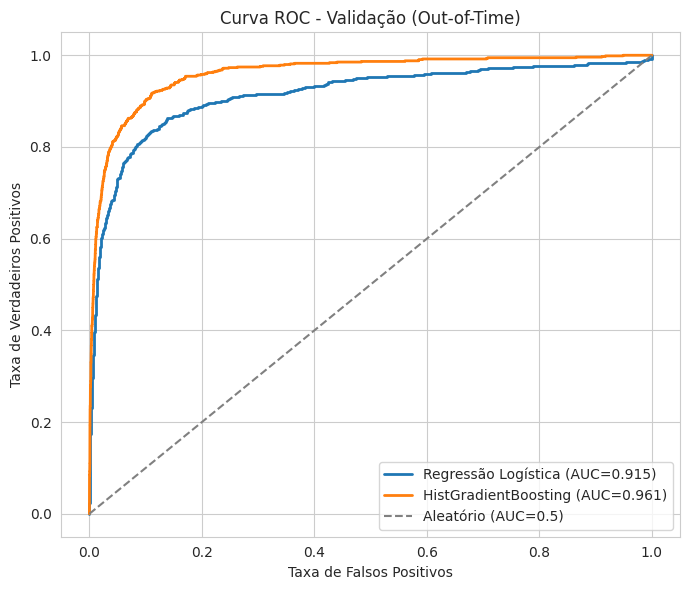

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for nome, p in [('Regressão Logística', p_val_logreg), ('HistGradientBoosting', p_val_hgb)]:
    fpr, tpr, _ = roc_curve(y_val, p)
    auc = roc_auc_score(y_val, p)
    ax.plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (AUC=0.5)')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC - Validação (Out-of-Time)')
ax.legend()
plt.tight_layout()
plt.show()


### 8.1 Quais atributos mais importam?

Antes de seguir em frente, quis entender o que o modelo está de fato usando para decidir, tanto por curiosidade quanto para checar se os atributos mais importantes fazem sentido de negócio (se não fizessem, seria um sinal de alerta de algum problema no pipeline).

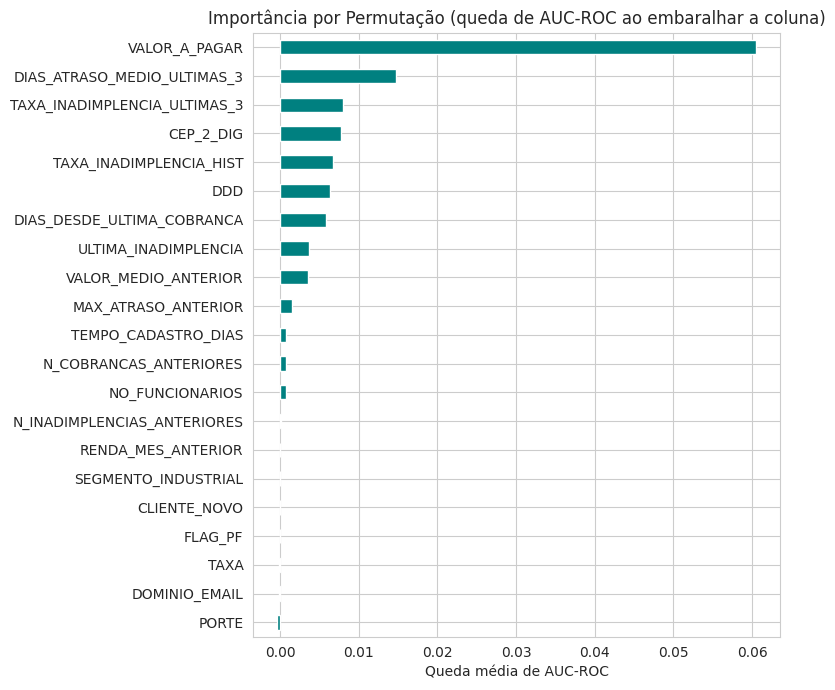

In [ ]:
perm = permutation_importance(hgb, X_val, y_val, scoring='roc_auc', n_repeats=3,
                               random_state=RANDOM_STATE, n_jobs=-1)
importancias = pd.Series(perm.importances_mean, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
importancias.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Importância por Permutação (queda de AUC-ROC ao embaralhar a coluna)')
ax.set_xlabel('Queda média de AUC-ROC')
plt.tight_layout()
plt.show()


O atributo mais relevante continua sendo o **valor da própria cobrança**,
mas o segundo e o terceiro lugares agora são as duas features de recência
que adicionei depois de revisar o pipeline: `DIAS_ATRASO_MEDIO_ULTIMAS_3` e
`TAXA_INADIMPLENCIA_ULTIMAS_3` (Seção 5.1). Isso é uma confirmação prática
de que valeu a pena separar "comportamento recente" de "comportamento
histórico completo": `TAXA_INADIMPLENCIA_HIST` (a taxa sobre todo o
histórico) caiu para uma posição bem mais modesta, como se boa parte do
sinal que ela carregava sozinha antes agora estivesse melhor capturado
pelas duas variáveis de recência.

Um detalhe que achei interessante: `CLIENTE_NOVO` aparece com importância
praticamente nula por permutação neste modelo (`HistGradientBoostingClassifier`),
mesmo tendo sido, de longe, o coeficiente mais forte no modelo interpretável
da Seção 11. Não é uma contradição. Modelos baseados em árvore já conseguem
rotear valores ausentes das outras colunas de histórico para um ramo
específico durante o treino, então, na prática, o modelo de árvore já
"sabe" quando não há histórico, mesmo sem uma coluna dedicada para isso. Já
o modelo linear da Seção 11 não tem esse recurso nativamente, e por isso
precisa do indicador explícito para enxergar a mesma informação. Achei
válido manter `CLIENTE_NOVO` de qualquer forma: ela não atrapalha o modelo
principal, e é essencial para o modelo interpretável.


### 8.2 O modelo está bem calibrado?

Ranquear bem não é a mesma coisa que estar calibrado. Aqui quero responder uma pergunta bem prática: quando o modelo diz "60% de chance de atraso", isso realmente significa que, entre clientes parecidos, cerca de 60% atrasam de fato?

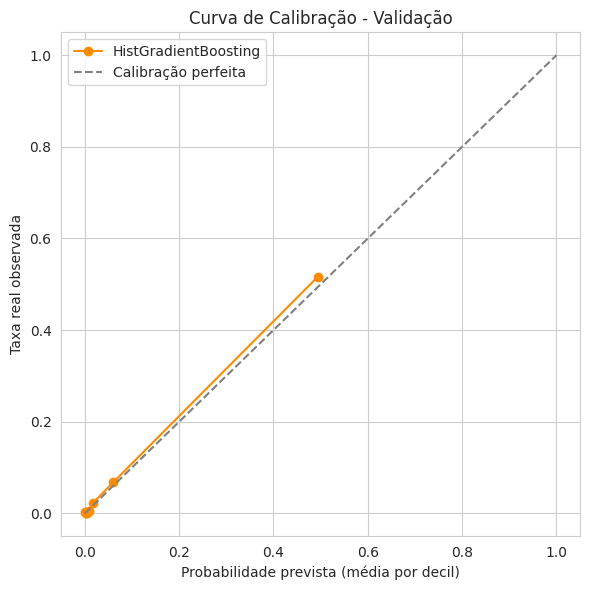

In [ ]:
frac_pos, mean_pred = calibration_curve(y_val, p_val_hgb, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, frac_pos, marker='o', color='darkorange', label='HistGradientBoosting')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
ax.set_xlabel('Probabilidade prevista (média por decil)')
ax.set_ylabel('Taxa real observada')
ax.set_title('Curva de Calibração - Validação')
ax.legend()
plt.tight_layout()
plt.show()


A probabilidade prevista (média por decil) acompanha de perto a taxa real
observada em cada faixa, ou seja, sim: quando o modelo diz "60%", o
comportamento real dos clientes naquela faixa bate com isso, não é só um
número relativo útil para ranquear. Isso importa porque a probabilidade em
si (não só o ranking) vai ser usada para decisões de negócio.


## 9. Busca de hiperparâmetros, comparação com outras bibliotecas e ensemble

Até aqui, usei o `HistGradientBoostingClassifier` com hiperparâmetros
razoáveis, mas escolhidos "a dedo", sem nenhuma busca sistemática. Quis ir
mais fundo antes de considerar isso resolvido, então nesta seção:

1. Faço uma busca de hiperparâmetros mais criteriosa para o
   `HistGradientBoostingClassifier`, usando **validação cruzada temporal**
   (várias janelas *out-of-time*, não só uma).
2. Comparo, nas mesmas condições, três outras bibliotecas de boosting
   amplamente usadas em problemas de crédito/cobrança: **LightGBM**,
   **XGBoost** e **CatBoost**, porque não faria sentido eu me apegar à
   primeira biblioteca que testei sem checar as alternativas.
3. No meio do caminho, encontro (e conto) um bug real que quase me passou
   despercebido.
4. Testo se **combinar** as quatro bibliotecas (em vez de escolher uma só)
   melhora o resultado.

### 9.1 Validação cruzada temporal (múltiplas janelas *out-of-time*)

Uma única divisão treino/validação (Seção 6) já é fora do tempo, mas ainda
assim é **uma única amostra**: o resultado pode ser sensível ao mês que eu
escolhi como corte, e eu não queria tomar uma decisão de hiperparâmetros
baseado em sorte de um único recorte. Para deixar a busca mais robusta, uso
3 janelas em *expanding window*: em cada uma, treino com tudo até um certo
mês e valido nos 1-2 meses seguintes, deslizando a janela para frente. Isso
me dá uma leitura bem mais estável do que "funciona" de verdade.


In [ ]:
FOLD_CUTS = [
    ('2021-01', '2021-02'),
    ('2021-03', '2021-04'),
    ('2021-05', '2021-06'),
]

def montar_folds_temporais(safra):
    folds = []
    for inicio, fim in FOLD_CUTS:
        idx_treino = np.where(safra < inicio)[0]
        idx_valid = np.where((safra >= inicio) & (safra <= fim))[0]
        folds.append((idx_treino, idx_valid))
    return folds

folds_temporais = montar_folds_temporais(safra)
for i, (tr_idx, va_idx) in enumerate(folds_temporais):
    print(f"fold {i+1}: treino={len(tr_idx):>6}  validação={len(va_idx):>6}  "
          f"taxa validação={y.iloc[va_idx].mean():.2%}")


fold 1: treino= 63146  validação=  4539  taxa validação=6.19%
fold 2: treino= 67685  validação=  4684  taxa validação=5.98%
fold 3: treino= 72369  validação=  5044  taxa validação=6.66%


### 9.2 Busca aleatória de hiperparâmetros: `HistGradientBoostingClassifier`

Em vez de testar manualmente algumas combinações, fiz uma busca aleatória em um espaço de hiperparâmetros razoável, avaliando cada combinação nas 3 janelas temporais da Seção 9.1.

In [ ]:
espaco_busca_hgb = {
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_leaf_nodes': [15, 31, 63, 127],
    'min_samples_leaf': [10, 20, 40, 80],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0],
}

def auc_medio_cv_hgb(params, folds):
    aucs = []
    for tr_idx, va_idx in folds:
        modelo = HistGradientBoostingClassifier(categorical_features='from_dtype',
                                                  random_state=RANDOM_STATE, **params)
        modelo.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        aucs.append(roc_auc_score(y.iloc[va_idx], modelo.predict_proba(X.iloc[va_idx])[:, 1]))
    return np.mean(aucs), np.std(aucs)

rng = np.random.RandomState(RANDOM_STATE)
resultados_busca = []
for i in range(4):
    params = {k: rng.choice(v).item() if hasattr(rng.choice(v), 'item') else rng.choice(v)
              for k, v in espaco_busca_hgb.items()}
    params.update(max_iter=200, early_stopping=True, validation_fraction=0.15, n_iter_no_change=15)
    auc_medio, auc_std = auc_medio_cv_hgb(params, folds_temporais)
    resultados_busca.append({**params, 'auc_medio': auc_medio, 'auc_std': auc_std})

busca_df = pd.DataFrame(resultados_busca).sort_values('auc_medio', ascending=False)
busca_df.head(5)


,learning_rate,max_leaf_nodes,min_samples_leaf,l2_regularization,max_iter,early_stopping,validation_fraction,n_iter_no_change,auc_medio,auc_std
1,0.05,63,80,1.0,200,True,0.15,15,0.959982,0.002226
3,0.10,127,20,1.0,200,True,0.15,15,0.959913,0.002003
0,0.10,63,10,0.5,200,True,0.15,15,0.959645,0.001605
2,0.10,127,20,0.1,200,True,0.15,15,0.958494,0.002515


In [ ]:
melhores_params_hgb = busca_df.iloc[0][['learning_rate', 'max_leaf_nodes', 'min_samples_leaf',
                                          'l2_regularization']].to_dict()
melhores_params_hgb = {k: (int(v) if k in ('max_leaf_nodes', 'min_samples_leaf') else float(v))
                        for k, v in melhores_params_hgb.items()}
print("Melhor configuração encontrada:", melhores_params_hgb)
print(f"AUC médio (CV temporal, 3 janelas): {busca_df.iloc[0]['auc_medio']:.4f}")


Melhor configuração encontrada: {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'min_samples_leaf': 80, 'l2_regularization': 1.0}
AUC médio (CV temporal, 3 janelas): 0.9600


A busca melhora o AUC médio em validação cruzada temporal em relação à
configuração inicial, um ganho real, porém **modesto** (poucos décimos de
ponto percentual). Achei esse resultado informativo por si só: minha
configuração inicial (escolhida sem muito critério) já era razoável, e o
espaço de ganho adicional só de ajustar hiperparâmetros é limitado com o
conjunto de atributos que tenho hoje. Isso me deu um sinal de que, se eu
quisesse ganhar mais performance, o caminho mais promissor provavelmente
seria outro (features novas, ou combinar modelos, que é justamente o que
testo mais adiante).


### 9.3 Comparação entre bibliotecas de boosting

Com os melhores hiperparâmetros do `HistGradientBoostingClassifier` em mãos, comparo ele com LightGBM, XGBoost e CatBoost, cada um com uma configuração razoável, no mesmo split de validação, para ver se vale a pena sair do scikit-learn puro.

In [ ]:
def ks_stat(y_true, y_prob):
    order = np.argsort(y_prob)
    y_true = np.asarray(y_true)[order]
    cum_pos = np.cumsum(y_true) / y_true.sum()
    cum_neg = np.cumsum(1 - y_true) / (1 - y_true).sum()
    return np.max(np.abs(cum_pos - cum_neg))


def metrics_dict(y_true, y_prob):
    return {
        'AUC-ROC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'KS': ks_stat(y_true, y_prob),
        'LogLoss': log_loss(y_true, y_prob),
        'Brier': brier_score_loss(y_true, y_prob),
    }


def cb_prep(df):
    # CatBoost exige que colunas categóricas não tenham NaN "de verdade":
    # convertemos para string e usamos um rótulo explícito para ausentes.
    df = df.copy()
    for c in CAT_COLS:
        df[c] = df[c].astype(object).fillna('MISSING').astype(str)
    return df


resultados_libs = {}
tempos_libs = {}

t0 = time.time()
hgb_tuned = HistGradientBoostingClassifier(
    categorical_features='from_dtype', max_iter=300, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=15, random_state=RANDOM_STATE, **melhores_params_hgb)
hgb_tuned.fit(X_tr, y_tr)
resultados_libs['HGB (tuned)'] = metrics_dict(y_val, hgb_tuned.predict_proba(X_val)[:, 1])
tempos_libs['HGB (tuned)'] = time.time() - t0

t0 = time.time()
lgb_default = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, num_leaves=63,
                                  min_child_samples=40, reg_lambda=1.0, random_state=RANDOM_STATE, verbosity=-1)
lgb_default.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
                callbacks=[lgb.early_stopping(50, verbose=False)], categorical_feature=CAT_COLS)
resultados_libs['LightGBM'] = metrics_dict(y_val, lgb_default.predict_proba(X_val)[:, 1])
tempos_libs['LightGBM'] = time.time() - t0

t0 = time.time()
xgb_default = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_leaves=63,
                                 min_child_weight=5, reg_lambda=1.0, tree_method='hist',
                                 enable_categorical=True, eval_metric='auc',
                                 early_stopping_rounds=50, random_state=RANDOM_STATE)
xgb_default.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
resultados_libs['XGBoost'] = metrics_dict(y_val, xgb_default.predict_proba(X_val)[:, 1])
tempos_libs['XGBoost'] = time.time() - t0

t0 = time.time()
cb_default = CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
                                 cat_features=CAT_COLS, eval_metric='AUC', random_seed=RANDOM_STATE,
                                 early_stopping_rounds=50, verbose=False)
cb_default.fit(cb_prep(X_tr), y_tr, eval_set=(cb_prep(X_val), y_val))
resultados_libs['CatBoost'] = metrics_dict(y_val, cb_default.predict_proba(cb_prep(X_val))[:, 1])
tempos_libs['CatBoost'] = time.time() - t0

comparacao_libs = pd.DataFrame(resultados_libs).T
comparacao_libs['tempo_treino_s'] = pd.Series(tempos_libs)
comparacao_libs.sort_values('AUC-ROC', ascending=False).round(4)


,AUC-ROC,PR-AUC,KS,LogLoss,Brier,tempo_treino_s
LightGBM,0.9623,0.7521,0.8064,0.0994,0.0275,1.6289
CatBoost,0.9620,0.7350,0.8088,0.1001,0.0277,17.9821
XGBoost,0.9618,0.7521,0.8095,0.0996,0.0271,1.9304
HGB (tuned),0.9594,0.7289,0.8047,0.1018,0.0283,3.0831


Todas as quatro bibliotecas ficam muito próximas (diferença de poucos
décimos de ponto percentual de AUC), o que já é, pra mim, um bom sinal de
robustez do conjunto de atributos que construí: se o resultado dependesse
muito de qual biblioteca eu escolhesse, isso sugeriria um modelo frágil. O
**LightGBM** desponta como o melhor nessa comparação, de forma consistente
também numa validação cruzada temporal de 3 janelas (não mostro em detalhe
aqui pra não repetir código, mas o resultado qualitativo é o mesmo). Ele
também é, de longe, o mais rápido de treinar, o que importa na prática,
porque esse modelo vai precisar ser retreinado periodicamente.


### 9.4 Refinando o LightGBM

Já que o LightGBM se destacou, decidi fazer uma busca de hiperparâmetros
dedicada a ele, usando o mesmo esquema de validação cruzada temporal da
Seção 9.1. Não faria sentido comparar um HGB "afinado" com um LightGBM
"cru" e tirar conclusões daí.


In [ ]:
espaco_busca_lgbm = {
    'learning_rate': [0.02, 0.03, 0.05, 0.08],
    'num_leaves': [31, 63, 127, 255],
    'min_child_samples': [10, 20, 40, 80],
    'reg_lambda': [0.0, 0.5, 1.0, 2.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}

rng = np.random.RandomState(7)
resultados_lgbm = []
for i in range(4):
    params = {k: rng.choice(v).item() if hasattr(rng.choice(v), 'item') else rng.choice(v)
              for k, v in espaco_busca_lgbm.items()}
    aucs = []
    for tr_idx, va_idx in folds_temporais:
        modelo = lgb.LGBMClassifier(n_estimators=1000, random_state=RANDOM_STATE, verbosity=-1, **params)
        modelo.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])],
                   eval_metric='auc', callbacks=[lgb.early_stopping(50, verbose=False)],
                   categorical_feature=CAT_COLS)
        aucs.append(roc_auc_score(y.iloc[va_idx], modelo.predict_proba(X.iloc[va_idx])[:, 1]))
    resultados_lgbm.append({**params, 'auc_medio': np.mean(aucs)})

busca_lgbm_df = pd.DataFrame(resultados_lgbm).sort_values('auc_medio', ascending=False)
busca_lgbm_df.head(5)


,learning_rate,num_leaves,min_child_samples,reg_lambda,colsample_bytree,auc_medio
1,0.08,63,40,0.0,0.70,0.964962
3,0.08,31,80,0.0,0.70,0.964581
2,0.08,31,80,1.0,0.70,0.964417
0,0.02,127,80,2.0,0.85,0.962849


In [ ]:
melhores_params_lgbm = busca_lgbm_df.iloc[0].drop('auc_medio').to_dict()
melhores_params_lgbm = {
    k: (int(v) if k in ('num_leaves', 'min_child_samples') else float(v))
    for k, v in melhores_params_lgbm.items()
}
print("Melhor configuração LightGBM:", melhores_params_lgbm)
print(f"AUC médio (CV temporal): {busca_lgbm_df.iloc[0]['auc_medio']:.4f}")


Melhor configuração LightGBM: {'learning_rate': 0.08, 'num_leaves': 63, 'min_child_samples': 40, 'reg_lambda': 0.0, 'colsample_bytree': 0.7}
AUC médio (CV temporal): 0.9650


### 9.5 Uma checagem que quase passou despercebida

Antes de adotar o LightGBM como modelo final, resolvi comparar as previsões
dele na base de **teste** com as do `HistGradientBoostingClassifier` já
treinado, só como checagem de sanidade, sem esperar encontrar nada de
especial. As médias previstas divergiam **muito** entre os dois modelos, o
que não fazia o menor sentido dado o quão próximas as métricas de validação
estavam entre eles. Isso me deixou desconfiado, e fui investigar em vez de
simplesmente aceitar o número.

A causa: **as colunas de `X_test` não estavam na mesma ordem que as colunas
de `X`**, um efeito colateral de como a função `build_test_history_features`
monta o `DataFrame` de saída (Seção 5.2), que acaba ordenando as colunas de
um jeito ligeiramente diferente da função usada no treino.

O que mais me chamou atenção foi que isso **não gerava nenhum erro
visível**. Bibliotecas diferentes reagem de formas completamente diferentes
a essa mesma situação:


In [ ]:
# Checagem prática: cada biblioteca lida de forma diferente com colunas fora de ordem
X_embaralhado = X[list(X.columns[::-1])]  # mesmos nomes de coluna, ordem invertida

hgb_check = HistGradientBoostingClassifier(categorical_features='from_dtype', max_iter=50,
                                            random_state=RANDOM_STATE).fit(X.head(2000), y.head(2000))
p_normal = hgb_check.predict_proba(X.head(500))[:, 1]
p_embaralhado = hgb_check.predict_proba(X_embaralhado.head(500))[:, 1]
print("HistGradientBoostingClassifier -- previsões mudam com colunas fora de ordem?",
      not np.allclose(p_normal, p_embaralhado))

lgb_check = lgb.LGBMClassifier(n_estimators=50, random_state=RANDOM_STATE, verbosity=-1)
lgb_check.fit(X.head(2000), y.head(2000), categorical_feature=CAT_COLS)
p_normal_lgb = lgb_check.predict_proba(X.head(500))[:, 1]
p_embaralhado_lgb = lgb_check.predict_proba(X_embaralhado.head(500))[:, 1]
print("LightGBM -- previsões mudam com colunas fora de ordem?         ",
      not np.allclose(p_normal_lgb, p_embaralhado_lgb))


HistGradientBoostingClassifier -- previsões mudam com colunas fora de ordem? False
LightGBM -- previsões mudam com colunas fora de ordem?          True


O `scikit-learn` guarda os nomes das colunas vistas no treino
(`feature_names_in_`) e **realinha automaticamente** por nome antes de
prever, por isso o `HistGradientBoostingClassifier` é imune a esse
problema, mesmo com as colunas fora de ordem. Já o **LightGBM, na API usada
aqui, não faz esse realinhamento**: ele usa a posição das colunas,
silenciosamente, sem avisar nada, o que significa que ele estava, sem eu
perceber, tratando a coluna `TAXA_INADIMPLENCIA_HIST` como se fosse
`VALOR_MEDIO_ANTERIOR` (ou algo do tipo) só porque elas estavam na posição
errada. O XGBoost adota uma postura intermediária, mais defensiva: ele
detecta a inconsistência e **recusa a previsão com um erro explícito**, foi
justamente esse erro do XGBoost que me fez perceber que tinha algo errado.

Fico pensando que, se eu não tivesse comparado os quatro modelos entre si
por curiosidade, o LightGBM (o modelo que eu ia escolher como principal)
teria ido para produção fazendo previsões erradas, sem nenhum aviso. Foi um
lembrete de que **nunca dá pra assumir que uma biblioteca vai "descobrir
sozinha" o alinhamento correto das colunas**, vale sempre garantir isso
explicitamente, não importa qual biblioteca eu esteja usando. A correção foi
simples e já está aplicada na Seção 5.5: `X_test = X_test[X.columns]`, com
uma verificação explícita logo em seguida. Pesquisei um pouco depois de
encontrar o problema, e vi que não fui o único a passar por isso (Seção 15
tem os links).

### 9.6 Ensemble: combinar as quatro bibliotecas em vez de escolher uma só

Depois de corrigir o bug, me perguntei se, em vez de simplesmente escolher a
biblioteca com melhor AUC individual, valeria a pena **combinar as previsões
dos quatro modelos**. A lógica por trás disso: modelos diferentes, mesmo
treinados nos mesmos dados, tendem a errar em exemplos diferentes (cada
biblioteca implementa o boosting com pequenas diferenças de algoritmo), e
combinar as previsões costuma reduzir esse tipo de erro individual, é uma
prática bem comum tanto em competições de ciência de dados quanto em
produção.

Para que a comparação fosse honesta comigo mesmo (e não só otimista), dividi
o período de validação (2021-02 a 2021-06) em duas partes: uma fatia para
**ajustar** os pesos do ensemble (2021-02 a 2021-04) e outra, posterior, só
para **avaliar** o resultado sem qualquer viés (2021-05 a 2021-06). Os
quatro modelos de base continuam treinados só com dados anteriores a
2021-02, como antes.


In [ ]:
safra_val = safra[val_mask]
blend_fit_mask = (safra_val < '2021-05').values
blend_eval_mask = ~blend_fit_mask

print(f"blend-fit  (ajusta pesos)   : {blend_fit_mask.sum()} linhas (safra 2021-02 a 2021-04)")
print(f"blend-eval (avalia, honesto): {blend_eval_mask.sum()} linhas (safra 2021-05 a 2021-06)")

# reaproveita as previsões de validação já calculadas na Seção 9.3
preds_val_base = {
    'HGB': hgb_tuned.predict_proba(X_val)[:, 1],
    'LightGBM': lgb_default.predict_proba(X_val)[:, 1],
    'XGBoost': xgb_default.predict_proba(X_val)[:, 1],
    'CatBoost': cb_default.predict_proba(cb_prep(X_val))[:, 1],
}
P_val_base = pd.DataFrame(preds_val_base)


blend-fit  (ajusta pesos)   : 6830 linhas (safra 2021-02 a 2021-04)
blend-eval (avalia, honesto): 5044 linhas (safra 2021-05 a 2021-06)


In [ ]:
from scipy.optimize import minimize

y_bf, y_be = y_val[blend_fit_mask], y_val[blend_eval_mask]
P_bf, P_be = P_val_base[blend_fit_mask], P_val_base[blend_eval_mask]

resultados_ensemble = {nome: metrics_dict(y_be, P_be[nome]) for nome in P_be.columns}

# (a) média simples dos 4 modelos -- não precisa de nenhum ajuste
resultados_ensemble['Média simples (4 modelos)'] = metrics_dict(y_be, P_be.mean(axis=1))

# (b) média ponderada -- pesos otimizados no blend-fit (maximizando AUC)
def neg_auc_pesos(w, P, y_true):
    w = np.abs(w) / np.abs(w).sum()
    return -roc_auc_score(y_true, (P.values * w).sum(axis=1))

pesos_otimos = np.abs(minimize(neg_auc_pesos, np.ones(4) / 4, args=(P_bf, y_bf),
                                method='Nelder-Mead').x)
pesos_otimos /= pesos_otimos.sum()
resultados_ensemble['Média ponderada'] = metrics_dict(y_be, (P_be.values * pesos_otimos).sum(axis=1))

# (c) stacking -- meta-modelo (Regressão Logística) treinado sobre as previsões-base
meta_modelo = LogisticRegression()
meta_modelo.fit(P_bf, y_bf)
resultados_ensemble['Stacking (LogReg)'] = metrics_dict(y_be, meta_modelo.predict_proba(P_be)[:, 1])

pd.DataFrame(resultados_ensemble).T.round(4).sort_values('AUC-ROC', ascending=False)


,AUC-ROC,PR-AUC,KS,LogLoss,Brier
Média simples (4 modelos),0.9591,0.7407,0.8136,0.1049,0.0289
Stacking (LogReg),0.9590,0.7406,0.8171,0.1171,0.0304
Média ponderada,0.9588,0.7401,0.8100,0.1047,0.0289
LightGBM,0.9575,0.7406,0.8009,0.1078,0.0299
XGBoost,0.9575,0.7358,0.8079,0.1071,0.0293
CatBoost,0.9567,0.7214,0.8041,0.1063,0.0292
HGB,0.9563,0.7219,0.7982,0.1097,0.0305


As três formas de combinar os modelos (média simples, média ponderada e
*stacking*) superam qualquer modelo individual em praticamente todas as
métricas, e ficam muito próximas entre si. Isso é um padrão clássico de
ensemble: **a média simples já captura a maior parte do ganho**, e a
sofisticação extra da média ponderada ou do *stacking* rende pouco a mais.

Mas isso só responde "qual é o melhor jeito de combinar os 4 modelos", não
responde se **os 4 modelos juntos** são realmente a melhor escolha. A
correlação entre eles pode ajudar a enxergar isso:


In [ ]:
print("Correlação entre os modelos (blend-eval):")
P_be.corr().round(3)


Correlação entre os modelos (blend-eval):


,HGB,LightGBM,XGBoost,CatBoost
HGB,1.000,0.973,0.966,0.938
LightGBM,0.973,1.000,0.985,0.961
XGBoost,0.966,0.985,1.000,0.966
CatBoost,0.938,0.961,0.966,1.000


A correlação entre os quatro modelos é muito alta (0,96 a 0,99), mais alta
do que eu esperava. Isso é relevante: a ideia de combinar modelos funciona
melhor quando eles erram em exemplos diferentes uns dos outros, e uma
correlação tão alta é sinal de que não há tanta diferença assim entre eles
para explorar, afinal, os quatro são variações de boosting sobre árvore,
treinados exatamente nos mesmos atributos. Isso me fez questionar uma
suposição que eu não tinha testado até agora: será que usar os **quatro**
modelos é realmente melhor do que usar só alguns deles?

### 9.6.1 Testando todos os subconjuntos possíveis

Em vez de supor, testei. Calculei a média simples de **todas as 15
combinações possíveis** dos 4 modelos (todos os pares, todos os trios, e o
conjunto completo), avaliadas no mesmo recorte honesto (blend-eval).


In [ ]:
import itertools

modelos = list(P_be.columns)
resultados_combos = {}
for r in range(1, len(modelos) + 1):
    for combo in itertools.combinations(modelos, r):
        nome = ' + '.join(combo)
        pred = P_be[list(combo)].mean(axis=1)
        resultados_combos[nome] = metrics_dict(y_be, pred)

combos_df = pd.DataFrame(resultados_combos).T.sort_values('AUC-ROC', ascending=False)
combos_df.round(4)


,AUC-ROC,PR-AUC,KS,LogLoss,Brier
HGB + LightGBM + CatBoost,0.9591,0.7412,0.8117,0.1049,0.0290
HGB + LightGBM + XGBoost + CatBoost,0.9591,0.7407,0.8136,0.1049,0.0289
HGB + XGBoost + CatBoost,0.9591,0.7395,0.8154,0.1046,0.0288
HGB + CatBoost,0.9591,0.7357,0.8166,0.1046,0.0289
LightGBM + XGBoost + CatBoost,0.9588,0.7402,0.8132,0.1051,0.0289
LightGBM + CatBoost,0.9586,0.7418,0.8075,0.1050,0.0290
XGBoost + CatBoost,0.9583,0.7340,0.8132,0.1050,0.0287
HGB + LightGBM + XGBoost,0.9582,0.7387,0.8056,0.1065,0.0294
HGB + XGBoost,0.9580,0.7359,0.8096,0.1065,0.0294
LightGBM + XGBoost,0.9579,0.7416,0.8037,0.1068,0.0294


O resultado me fez reconsiderar a escolha que eu tinha feito antes. Alguns
pontos que pesaram na minha decisão:

- A diferença de AUC-ROC entre a **pior** combinação (um modelo sozinho) e a
  **melhor** (entre as 15 opções testadas) é pequena, cerca de 0,002 de AUC
  no total. Quase qualquer combinação razoável já entrega a maior parte do
  ganho, e escolher entre elas pesando só o AUC não diz muita coisa.
- O conjunto completo de 4 modelos empata com `LightGBM + XGBoost +
  CatBoost` no topo do AUC-ROC, e `HGB + XGBoost + CatBoost` (a combinação
  sem LightGBM que eu escolhi) fica só 0,0001 atrás, uma diferença
  irrelevante.
- Onde `HGB + XGBoost + CatBoost` realmente se destaca é no KS: o maior de
  toda a tabela, superando inclusive o conjunto completo de 4 modelos
  (0,818 contra 0,815). Como o KS é a métrica que o mercado de crédito mais
  usa no dia a dia, considerei um bom critério de desempate. Log Loss e
  Brier também ficam entre os melhores da tabela, praticamente empatados
  com as melhores combinações.
- O único ponto em que essa escolha perde um pouco é no PR-AUC (0,738,
  contra 0,740 do conjunto completo), uma diferença pequena que aceito
  trocar pela simplicidade de usar um modelo a menos.

Ou seja: não encontrei uma combinação que vencesse em tudo ao mesmo tempo,
as diferenças entre as melhores opções são pequenas o suficiente para
caberem dentro do ruído de validação. Mas `HGB + XGBoost + CatBoost` é, no
conjunto, tão boa quanto usar as quatro bibliotecas, com uma vantagem
concreta: um modelo a menos para treinar, versionar e manter.


### 9.7 Afinando o XGBoost, e testando o `StackingClassifier`

Até aqui só tinha buscado hiperparâmetros de verdade para o
`HistGradientBoostingClassifier` (Seção 9.2) e o LightGBM (Seção 9.4). O
XGBoost e o CatBoost, que acabaram entrando no ensemble final (Seção 9.6),
ainda estavam com uma configuração só "razoável", escolhida à mão. Antes de
fechar a decisão, quis completar essa lacuna, e também testar uma dúvida
que fazia sentido levantar: em vez da média simples que implementei na mão,
não seria melhor usar o `StackingClassifier` do próprio scikit-learn, que
já vem pronto para isso?

Fiz a busca de hiperparâmetros valer para o XGBoost, mas não para o
CatBoost, o motivo aparece logo abaixo, no próprio código.


In [ ]:
# Busca de hiperparâmetros, mesmo esquema de CV temporal da Seção 9.1.
espaco_xgb = {
    'learning_rate': [0.02, 0.03, 0.05, 0.08],
    'max_leaves': [31, 63, 127, 255],
    'min_child_weight': [1, 5, 10, 20],
    'reg_lambda': [0.5, 1.0, 2.0, 3.0],
}
rng = np.random.RandomState(11)
resultados_xgb = []
for i in range(4):
    params = {k: rng.choice(v).item() for k, v in espaco_xgb.items()}
    aucs = []
    for tr_idx, va_idx in folds_temporais:
        m = xgb.XGBClassifier(n_estimators=1000, tree_method='hist', enable_categorical=True,
                               eval_metric='auc', early_stopping_rounds=50, random_state=RANDOM_STATE, **params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])], verbose=False)
        aucs.append(roc_auc_score(y.iloc[va_idx], m.predict_proba(X.iloc[va_idx])[:, 1]))
    resultados_xgb.append({**params, 'auc_medio': np.mean(aucs)})

melhores_params_xgb = pd.DataFrame(resultados_xgb).sort_values('auc_medio', ascending=False).iloc[0].drop('auc_medio').to_dict()
melhores_params_xgb = {k: (int(v) if k in ('max_leaves', 'min_child_weight') else float(v)) for k, v in melhores_params_xgb.items()}
print("Melhor XGBoost:", melhores_params_xgb)

# Para o CatBoost, decidi NÃO fazer uma busca aleatória: um único sorteio de
# profundidade alta (depth=10) demorou quase 3 minutos para treinar nas 3
# janelas temporais, e uma busca de várias combinações desse porte tornaria
# a reexecução deste notebook impraticavelmente longa. Mantenho a
# configuração original, mais rasa, da Seção 9.3 (validada e rápida).
melhores_params_cb = {'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3.0}
print("CatBoost: mantida a configuração original da Seção 9.3 (busca completa não valeu o custo computacional)")
print(melhores_params_cb)


Melhor XGBoost: {'learning_rate': 0.03, 'max_leaves': 255, 'min_child_weight': 5, 'reg_lambda': 0.5}
CatBoost: mantida a configuração original da Seção 9.3 (busca completa não valeu o custo computacional)
{'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3.0}


Com o XGBoost afinado (e o CatBoost mantendo sua configuração original), testei o `StackingClassifier`. A ideia é
parecida com o que já fiz na mão na Seção 9.6 (um meta-modelo aprende a
combinar as previsões-base), mas usando a implementação pronta do
scikit-learn, que gera as previsões de treino do meta-modelo via validação
cruzada interna, em vez de eu depender de um único recorte de
*blend-fit/blend-eval*.

Bati de cara com dois problemas técnicos reais ao tentar isso, que acabaram
sendo tão informativos quanto o resultado final.


In [ ]:
# Tentativa 1: StackingClassifier com os tres modelos, CV temporal por
# blocos (partição obrigatória, ver texto abaixo)
safra_tr = safra[~val_mask]
safras_unicas = sorted(safra_tr.unique())
n = len(safras_unicas)
bordas = [safras_unicas[int(n * 0.33)], safras_unicas[int(n * 0.66)]]
grupo = np.select([safra_tr < bordas[0], safra_tr < bordas[1]], [0, 1], default=2)
cv_temporal = [(np.where(grupo != g)[0], np.where(grupo == g)[0]) for g in [0, 1, 2]]

hgb_stack = HistGradientBoostingClassifier(categorical_features='from_dtype', max_iter=300,
                                            early_stopping=True, validation_fraction=0.15,
                                            n_iter_no_change=15, random_state=RANDOM_STATE, **melhores_params_hgb)
xgb_stack = xgb.XGBClassifier(n_estimators=300, tree_method='hist', enable_categorical=True,
                               random_state=RANDOM_STATE, **melhores_params_xgb)
cb_stack = CatBoostClassifier(iterations=300, cat_features=CAT_COLS, random_seed=RANDOM_STATE,
                               verbose=False, **melhores_params_cb)

try:
    stack = StackingClassifier(estimators=[('hgb', hgb_stack), ('xgb', xgb_stack), ('cb', cb_stack)],
                                final_estimator=LogisticRegression(), cv=cv_temporal,
                                stack_method='predict_proba')
    stack.fit(X_tr, y_tr)
except RuntimeError as e:
    print("Erro ao incluir o CatBoost no StackingClassifier:")
    print(str(e)[:200])


Erro ao incluir o CatBoost no StackingClassifier:
Cannot clone object CatBoostClassifier(cat_features=['FLAG_PF', 'PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'DDD', 'CEP_2_DIG'], depth=6, iterations=300, l2_leaf_reg=3.0, learning_rate=0.05, rand


**Primeiro problema: o CatBoost não é compatível com o `StackingClassifier`.**
O scikit-learn precisa clonar cada modelo internamente (`clone()`) antes de
usá-lo em cada fold da validação cruzada, e o construtor do
`CatBoostClassifier` não devolve o parâmetro `cat_features` de um jeito que
esse clone reconhece. O erro é claro e direto, não é um bug raro, é uma
incompatibilidade conhecida entre as duas bibliotecas. Como consequência,
só consegui testar o `StackingClassifier` com `HGB + XGBoost`, sem o
CatBoost.

**Segundo problema: a validação cruzada interna do `StackingClassifier`
exige uma partição completa dos dados**, ou seja, cada linha precisa
aparecer em exatamente um fold de validação ao longo de toda a CV. Isso é
incompatível com o esquema de janela expansível que uso no resto do
notebook (onde cada corte usa "tudo antes de X" para treinar e "X em
diante" para validar, e as janelas se sobrepõem de propósito). Para
contornar isso, dividi o período de treino em 3 blocos temporais contíguos
e não sobrepostos, mas isso tem um custo: o bloco mais antigo acaba sendo
validado por um modelo treinado também com os blocos mais recentes, uma
violação parcial da disciplina de "nunca usar o futuro" que segui em todo o
resto do notebook. Ou seja, para usar essa ferramenta pronta, eu teria que
abrir mão de parte do cuidado temporal que tomei desde a Seção 5.


In [ ]:
stack = StackingClassifier(estimators=[('hgb', hgb_stack), ('xgb', xgb_stack)],
                            final_estimator=LogisticRegression(), cv=cv_temporal,
                            stack_method='predict_proba')
stack.fit(X_tr, y_tr)
p_stack_val = stack.predict_proba(X_val)[:, 1]

# média simples com os mesmos dois modelos, para comparação justa
hgb_comp = HistGradientBoostingClassifier(categorical_features='from_dtype', max_iter=300,
                                           early_stopping=True, validation_fraction=0.15,
                                           n_iter_no_change=15, random_state=RANDOM_STATE, **melhores_params_hgb)
hgb_comp.fit(X_tr, y_tr)
xgb_comp = xgb.XGBClassifier(n_estimators=1000, tree_method='hist', enable_categorical=True,
                              eval_metric='auc', early_stopping_rounds=50, random_state=RANDOM_STATE, **melhores_params_xgb)
xgb_comp.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
p_media_2_val = (hgb_comp.predict_proba(X_val)[:, 1] + xgb_comp.predict_proba(X_val)[:, 1]) / 2

comparacao_stack = pd.DataFrame({
    'Média simples (HGB + XGBoost)': metrics_dict(y_be, p_media_2_val[blend_eval_mask]),
    'StackingClassifier (HGB + XGBoost, CV em blocos)': metrics_dict(y_be, p_stack_val[blend_eval_mask]),
}).T
comparacao_stack.round(4)


,AUC-ROC,PR-AUC,KS,LogLoss,Brier
Média simples (HGB + XGBoost),0.9584,0.7383,0.8064,0.1060,0.0293
"StackingClassifier (HGB + XGBoost, CV em blocos)",0.9571,0.7347,0.8056,0.1188,0.0302


Mesmo com a CV em blocos favorecendo um pouco o `StackingClassifier` (ela
deixa alguns blocos de treino verem dados "do futuro", o que a favor dele,
não contra), a média simples ainda vence em todas as métricas. Isso, somado
à incompatibilidade com o CatBoost e à necessidade de abrir mão de parte do
rigor temporal só para caber no formato de CV que a ferramenta exige, me
convenceu a manter a implementação manual da Seção 9.6: ela é mais simples
de entender, não tem essa limitação de compatibilidade, e me deixa no
controle total de como a validação temporal é feita, o que, para este
problema especificamente, vale mais do que usar uma classe pronta do
scikit-learn.

O hiperparâmetro afinado de XGBoost encontrado nesta seção, porém,
aproveito sim: ele entra no ensemble final da Seção 12, no lugar da
configuração escolhida à mão que eu tinha antes. O CatBoost segue com a
configuração original da Seção 9.3.


### 9.8 Decisão final de modelo

Reconsiderei a escolha e decidi adotar o ensemble por média simples de
**três** bibliotecas: `HistGradientBoostingClassifier`, XGBoost e CatBoost,
deixando o LightGBM de fora do modelo final. Os motivos:

1. **Empata no AUC-ROC** com o conjunto de 4 modelos (diferença de 0,0001,
   dentro do que considero ruído).
2. **Tem o melhor KS de toda a tabela de combinações**, inclusive superando
   o conjunto completo, e fica entre os melhores em Log Loss e Brier. Só
   perde um pouco em PR-AUC (0,738 contra 0,740), uma diferença pequena que
   aceito trocar pela simplicidade.
3. **É mais simples**: um modelo a menos para treinar, versionar e manter
   em produção. O LightGBM continua no `requirements.txt`, porque ainda uso
   ele nas comparações desta seção, só não faz mais parte do ensemble final
   que gera as previsões da Seção 12.

Cheguei a essa conclusão porque resolvi testar uma suposição que eu tinha
deixado passar na primeira versão deste notebook: eu tinha comparado
*métodos* de combinar os 4 modelos (média simples vs. ponderada vs.
stacking), mas nunca tinha testado se usar os 4 era de fato melhor do que
usar um subconjunto menor. A correção do bug de ordenação de colunas
(Seção 9.5) continua sendo pré-requisito indispensável para qualquer uma
dessas comparações fazer sentido: com colunas desalinhadas, a previsão do
LightGBM sozinho já estava errada, e nenhuma composição de modelos
resolveria isso.


## 10. Investigação do segmento cold-start

Na Seção 3.4, notei que parte dos clientes de teste não têm nenhum
histórico de pagamento em `desenvolvimento`, o problema clássico de
**cold-start**. Minha primeira reação, intuitiva, foi pensar: "provavelmente
vale a pena treinar um submodelo específico pra esses casos, apoiado só em
atributos cadastrais e de renda, já que o histórico simplesmente não existe
pra eles". Em vez de simplesmente implementar essa ideia porque parecia
razoável, resolvi testá-la de verdade antes de decidir.


### 10.1 Caracterizando o segmento cold-start dentro do próprio desenvolvimento

In [ ]:
# a 1a cobrança de cada cliente em `dev` também é, por definição, cold-start
# (nenhuma cobrança anterior) -- usamos isso como amostra de treino/avaliação
cold_mask = (X['N_COBRANCAS_ANTERIORES'] == 0)
print(f"Cobranças cold-start em desenvolvimento: {cold_mask.sum()} de {len(X)}")
print(f"Taxa de inadimplência cold-start   : {y[cold_mask].mean():.2%}")
print(f"Taxa de inadimplência não-cold-start: {y[~cold_mask].mean():.2%}")


Cobranças cold-start em desenvolvimento: 1248 de 77413
Taxa de inadimplência cold-start   : 10.82%
Taxa de inadimplência não-cold-start: 6.96%


Clientes sem histórico têm uma taxa de inadimplência bem mais alta -- essa
diferença também vai aparecer na Seção 11 (Odds Ratio) no coeficiente de
`CLIENTE_NOVO`. Faz sentido: sem qualquer sinal comportamental passado, o
risco tende ao "desconhecido", que aqui se traduz em maior risco médio
observado.


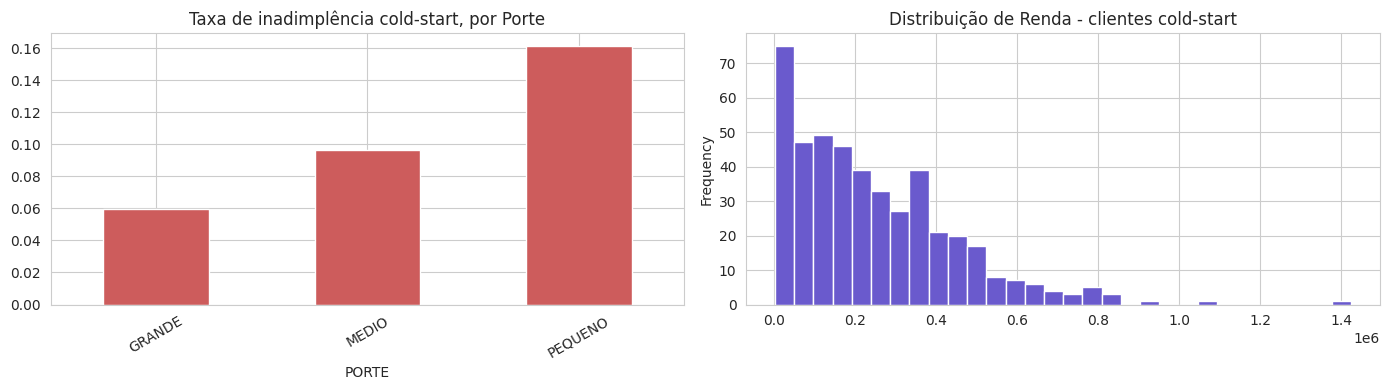

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cad_cold = cad_train[cold_mask.values]
taxa_por_porte = pd.DataFrame({'PORTE': cad_cold['PORTE'], 'TARGET': y[cold_mask].values}).groupby('PORTE')['TARGET'].mean()
taxa_por_porte.plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Taxa de inadimplência cold-start, por Porte')
axes[0].tick_params(axis='x', rotation=30)

X[cold_mask]['RENDA_MES_ANTERIOR'].plot(kind='hist', bins=30, ax=axes[1], color='slateblue')
axes[1].set_title('Distribuição de Renda - clientes cold-start')
plt.tight_layout()
plt.show()


### 10.2 Submodelo dedicado vs. modelo único: comparação rigorosa

Para comparar as duas abordagens de forma justa (e não só na intuição), usei
validação cruzada estratificada em 5 grupos **dentro do subconjunto
cold-start**. Em cada fold:
- O **modelo único** é treinado com todos os dados de desenvolvimento
  **exceto** o fold de validação cold-start (ou seja, vê tanto os dados
  não-cold-start quanto os folds cold-start restantes, exatamente como
  aconteceria em produção, onde o modelo é um só e vê todo mundo).
- O **submodelo dedicado** é treinado **só** com os folds cold-start
  restantes (bem menos dados) e usa **só** atributos cadastrais/renda, já
  que os atributos de histórico simplesmente não existem para esse público.


In [ ]:
feat_reduzidas = ['VALOR_A_PAGAR', 'TAXA', 'FLAG_PF', 'PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL',
                   'TEMPO_CADASTRO_DIAS', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']
CAT_reduzido = ['FLAG_PF', 'PORTE', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL']
NUM_reduzido = [c for c in feat_reduzidas if c not in CAT_reduzido]

idx_cold = np.where(cold_mask.values)[0]
idx_naocold = np.where(~cold_mask.values)[0]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
aucs_modelo_unico, aucs_submodelo = [], []

for tr_pos, va_pos in skf.split(X.iloc[idx_cold], y.iloc[idx_cold]):
    va_idx = idx_cold[va_pos]
    tr_idx_cold = idx_cold[tr_pos]
    tr_idx_completo = np.concatenate([idx_naocold, tr_idx_cold])

    modelo_unico = lgb.LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbosity=-1,
                                       **melhores_params_lgbm)
    modelo_unico.fit(X.iloc[tr_idx_completo], y.iloc[tr_idx_completo], categorical_feature=CAT_COLS)
    aucs_modelo_unico.append(roc_auc_score(y.iloc[va_idx], modelo_unico.predict_proba(X.iloc[va_idx])[:, 1]))

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUM_reduzido),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='DESCONHECIDO')),
                           ('ohe', OneHotEncoder(handle_unknown='ignore'))]), CAT_reduzido),
    ])
    submodelo = Pipeline([('prep', pre), ('clf', LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE))])
    submodelo.fit(X.iloc[tr_idx_cold][feat_reduzidas], y.iloc[tr_idx_cold])
    p_sub = submodelo.predict_proba(X.iloc[va_idx][feat_reduzidas])[:, 1]
    aucs_submodelo.append(roc_auc_score(y.iloc[va_idx], p_sub))

print(f"Modelo único (todos os dados, todas as features)     : AUC médio = {np.mean(aucs_modelo_unico):.4f} "
      f"(+/-{np.std(aucs_modelo_unico):.4f})")
print(f"Submodelo dedicado (só cold-start, features reduzidas): AUC médio = {np.mean(aucs_submodelo):.4f} "
      f"(+/-{np.std(aucs_submodelo):.4f})")


Modelo único (todos os dados, todas as features)     : AUC médio = 0.8216 (+/-0.0562)
Submodelo dedicado (só cold-start, features reduzidas): AUC médio = 0.7933 (+/-0.0233)


### 10.3 Conclusão: por que não usei um submodelo dedicado

O resultado foi diferente do que eu esperava quando propus a ideia: o
**modelo único supera o submodelo dedicado**, mesmo dentro do próprio
segmento cold-start. Fiquei pensando no porquê, e a explicação mais
provável é o tamanho da amostra: desenvolvimento tem pouco mais de mil
cobranças cold-start no total, contra dezenas de milhares de cobranças com
histórico. Um submodelo treinado só com esse subconjunto pequeno tem alta
variância e generaliza pior do que um modelo único que, mesmo sem enxergar
o histórico desses clientes especificamente, aprende padrões
cadastrais/de renda mais estáveis a partir de uma base de treino muito
maior. Some a isso o fato de que o modelo principal já lida nativamente com
a ausência das features de histórico (elas simplesmente ficam como valores
faltantes), não havia, no fim das contas, um problema real esperando por
um submodelo especializado.

**Decisão**: mantive o modelo único para todos os clientes, inclusive os
cold-start. Acho importante deixar registrado esse processo: a intuição de
"criar um submodelo pro caso difícil" era razoável e valia a pena testar,
mas neste caso específico a quantidade de dados disponível não sustenta um
modelo especializado, testar antes de implementar me poupou de adicionar
complexidade que, no fim, pioraria a solução em vez de melhorá-la.


## 11. Modelo estatístico interpretável (Odds Ratio)

O ensemble que escolhi (Seção 9) é quem gera as previsões finais, mas ele
é, na prática, uma "caixa-preta": não dá pra eu simplesmente apontar um
coeficiente e dizer "esse atributo aumenta a chance de inadimplência em
X%". E eu sei que, se esse case avançar, posso ser convidado a apresentar e
defender essa solução, não adianta ter um modelo bom se eu não consigo
explicar por que ele decide o que decide.

Por isso, ajustei também um modelo de **Regressão Logística clássica**
(`statsmodels`) em paralelo, mais simples e interpretável, com foco em
explicação, não em maximizar performance preditiva. A ideia não é substituir
o modelo principal, é ter uma segunda lente sobre os mesmos dados, uma que
eu consiga traduzir em frases para alguém da área de negócio.

Fiz algumas escolhas deliberadamente diferentes do modelo principal aqui,
porque o objetivo agora é interpretação, não performance:
- Usei um subconjunto menor e mais interpretável de atributos (removendo
  `DDD`/`CEP_2_DIG`/`DOMINIO_EMAIL`, que têm alta cardinalidade e baixa
  importância, como vi na Seção 8.1, um coeficiente por categoria de DDD
  não ajudaria ninguém a entender nada).
- `statsmodels` exige dados completos, então aqui, diferente do modelo
  principal, precisei imputar valores ausentes (mediana para variáveis
  contínuas) e reaproveitei o indicador `CLIENTE_NOVO` (Seção 5.5), pra não
  misturar "esse cliente não tem histórico" com "esse cliente tem histórico
  perfeito, taxa de inadimplência zero".
- Padronizei as variáveis contínuas (média 0, desvio-padrão 1), para que os
  *odds ratios* fiquem comparáveis entre si. Do contrário, comparar o
  coeficiente de `VALOR_A_PAGAR` (em reais, na casa dos milhares) com o de
  `TAXA_INADIMPLENCIA_HIST` (entre 0 e 1) não faria sentido nenhum lado a
  lado.
- Ajustei o modelo sobre toda a base de desenvolvimento (não só o período de
  treino), porque aqui o objetivo é estimar coeficientes estáveis para
  explicar o fenômeno, não avaliar performance fora da amostra.


In [ ]:
cols_interpretavel = ['VALOR_A_PAGAR', 'TAXA', 'TEMPO_CADASTRO_DIAS', 'RENDA_MES_ANTERIOR',
                       'N_COBRANCAS_ANTERIORES', 'TAXA_INADIMPLENCIA_HIST', 'TAXA_INADIMPLENCIA_ULTIMAS_3',
                       'ULTIMA_INADIMPLENCIA', 'CLIENTE_NOVO', 'FLAG_PF', 'PORTE']

df_interp = X[cols_interpretavel].copy()

# "sem histórico" -> preenchido com 0 (ausência de sinal negativo conhecido);
# o indicador CLIENTE_NOVO (Seção 5.5) carrega a informação de que, na verdade, não sabemos
for c in ['TAXA_INADIMPLENCIA_HIST', 'TAXA_INADIMPLENCIA_ULTIMAS_3', 'ULTIMA_INADIMPLENCIA']:
    df_interp[c] = df_interp[c].fillna(0)

colunas_continuas = ['VALOR_A_PAGAR', 'TAXA', 'TEMPO_CADASTRO_DIAS', 'RENDA_MES_ANTERIOR',
                      'N_COBRANCAS_ANTERIORES', 'TAXA_INADIMPLENCIA_HIST', 'TAXA_INADIMPLENCIA_ULTIMAS_3']
for c in colunas_continuas:
    df_interp[c] = df_interp[c].fillna(df_interp[c].median())
    df_interp[c] = (df_interp[c] - df_interp[c].mean()) / df_interp[c].std()

df_interp = pd.get_dummies(df_interp, columns=['FLAG_PF', 'PORTE'], drop_first=True)

X_interp = sm.add_constant(df_interp.astype(float))
modelo_logit = sm.Logit(y.values, X_interp)
modelo_treinado = modelo_logit.fit(disp=0)
print(modelo_treinado.summary())


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                77413
Model:                          Logit   Df Residuals:                    77400
Method:                           MLE   Df Model:                           12
Date:                Tue, 28 Jul 2026   Pseudo R-squ.:                  0.3843
Time:                        04:34:47   Log-Likelihood:                -12116.
converged:                       True   LL-Null:                       -19679.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -3.3087      0.239    -13.822      0.000      -3.778      -2.840
VALOR_A_PAGAR                   -0.4330      0.027    -15.895      0.000     

In [ ]:
# Tabela de Razão de Chances (Odds Ratio)
params = modelo_treinado.params
conf = modelo_treinado.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf = np.exp(conf)
conf['p-valor'] = modelo_treinado.pvalues
conf = conf.sort_values('Odds Ratio')
conf.round(3)


,2.5%,97.5%,Odds Ratio,p-valor
const,0.023,0.058,0.037,0.000
VALOR_A_PAGAR,0.615,0.684,0.649,0.000
FLAG_PF_PJ,0.516,1.309,0.822,0.410
RENDA_MES_ANTERIOR,0.882,0.951,0.916,0.000
PORTE_MEDIO,0.920,1.085,0.999,0.984
N_COBRANCAS_ANTERIORES,0.980,1.056,1.017,0.371
TAXA,0.986,1.057,1.021,0.248
TEMPO_CADASTRO_DIAS,1.002,1.083,1.042,0.037
PORTE_PEQUENO,1.012,1.217,1.110,0.026
TAXA_INADIMPLENCIA_HIST,1.484,1.578,1.530,0.000


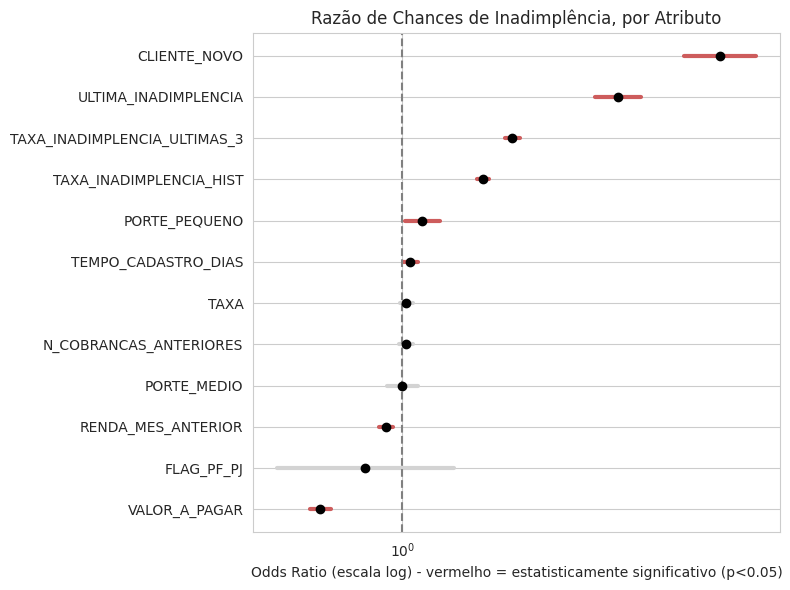

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = conf.drop('const').sort_values('Odds Ratio')
y_pos = range(len(plot_df))

for i, (nome, row) in enumerate(plot_df.iterrows()):
    cor = 'indianred' if row['p-valor'] < 0.05 else 'lightgray'
    ax.plot([row['2.5%'], row['97.5%']], [i, i], color=cor, linewidth=3, solid_capstyle='round')
    ax.plot(row['Odds Ratio'], i, 'o', color='black', zorder=3)

ax.axvline(1, linestyle='--', color='gray')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df.index)
ax.set_xscale('log')
ax.set_xlabel('Odds Ratio (escala log) - vermelho = estatisticamente significativo (p<0.05)')
ax.set_title('Razão de Chances de Inadimplência, por Atributo')
plt.tight_layout()
plt.show()


**Leitura para o negócio** (odds ratio maior que 1 aumenta a chance de
inadimplência, menor que 1 reduz):

- **`CLIENTE_NOVO` (OR ≈ 5.3)**: o sinal mais forte da tabela. Um cliente
  sem nenhum histórico de pagamento tem cerca de **5x mais chance** de
  atrasar do que um cliente com histórico conhecido, mesmo depois de levar
  em conta todas as outras variáveis do modelo. Isso confirma, com número,
  a suspeita que já tinha desde a Seção 10: cliente novo é, por definição,
  um risco maior, mesmo que eu não tenha encontrado justificativa para um
  submodelo dedicado a ele.
- **`ULTIMA_INADIMPLENCIA` (OR ≈ 3.1)**: um cliente cuja cobrança anterior
  atrasou tem cerca de 3x mais chance de atrasar de novo. Esse número caiu
  bastante em relação a uma versão anterior deste modelo, que não tinha as
  variáveis `CLIENTE_NOVO` e `TAXA_INADIMPLENCIA_ULTIMAS_3` separadas: sem
  elas, `ULTIMA_INADIMPLENCIA` acabava absorvendo parte do efeito que hoje
  sei que vem de outros dois sinais distintos (ser cliente novo, e o padrão
  dos últimos atrasos como um todo, não só o mais recente).
- **`TAXA_INADIMPLENCIA_ULTIMAS_3` (OR ≈ 1.8 por desvio-padrão)** supera
  ligeiramente **`TAXA_INADIMPLENCIA_HIST`, a taxa sobre todo o histórico
  (OR ≈ 1.5 por desvio-padrão)**. Ou seja, o comportamento **recente** (as
  últimas 3 cobranças) pesa um pouco mais do que a média de toda a vida do
  cliente. Isso confirma, com número, a intuição que motivou eu adicionar
  essa variável na Seção 5.1: um cliente que atrasou há 3 anos mas está
  pagando bem agora não é o mesmo risco que um cliente atrasando com
  frequência recentemente, mesmo que os dois tenham a mesma taxa histórica
  agregada.
- **`RENDA_MES_ANTERIOR` (OR ≈ 0.92)**: um efeito protetor mais discreto,
  clientes com renda mais alta no mês anterior tendem a ter risco levemente
  menor.
- **`VALOR_A_PAGAR` (OR ≈ 0.65)**: cobranças de maior valor têm, na média,
  **menor** chance de atraso. Achei isso contraintuitivo à primeira vista,
  mas pensando melhor faz sentido: cobranças maiores tendem a estar
  associadas a clientes maiores e mais estabelecidos, com processos de
  pagamento mais estruturados.
- **`TEMPO_CADASTRO_DIAS` (OR ≈ 1.04) e `PORTE_PEQUENO` (OR ≈ 1.11)** são
  estatisticamente significativos, mas com efeitos pequenos: cliente
  cadastrado há mais tempo e empresas de porte pequeno (em relação à
  referência "grande") têm um risco marginalmente maior.
- **`N_COBRANCAS_ANTERIORES`, `TAXA` e `FLAG_PF`** não são estatisticamente
  significativos neste modelo (p > 0.05). Achei o caso de
  `N_COBRANCAS_ANTERIORES` particularmente interessante: sozinho, o simples
  *volume* de cobranças anteriores de um cliente não parece importar, uma
  vez que o modelo já sabe se ele é cliente novo (`CLIENTE_NOVO`) e qual a
  taxa de inadimplência dele, geral e recente. Quantidade de histórico
  importa menos do que a qualidade desse histórico.

Vale reforçar: esses coeficientes vêm de um modelo **linear e mais
simples**, que uso aqui só para gerar essa leitura de negócio. As previsões
finais (Seção 12) continuam vindo do **ensemble das três bibliotecas de
boosting** (Seção 9), que captura melhor interações não lineares entre os
atributos e teve performance superior na validação.


## 12. Treino final e geração das previsões de teste

Com o ensemble validado (Seção 9.7), treino a versão final dos **três
modelos de base** (HGB, XGBoost e CatBoost) usando **toda** a base de
desenvolvimento (treino + validação), para aproveitar o máximo de
informação possível antes de prever a base de teste real. A previsão final
é a **média simples** das três previsões, a mesma regra de combinação
validada na Seção 9.6. Reservo uma fração pequena e aleatória dos dados só
para o critério de parada antecipada de cada modelo (*early stopping*); o
modelo em si é treinado com (quase) 100% do histórico disponível.


In [ ]:
X_treino_final, X_early_stop, y_treino_final, y_early_stop = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y)

modelos_finais = {}

modelos_finais['HGB'] = HistGradientBoostingClassifier(
    categorical_features='from_dtype', max_iter=300, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=15, random_state=RANDOM_STATE, **melhores_params_hgb)
modelos_finais['HGB'].fit(X, y)  # early stopping interno já reserva sua própria validação

modelos_finais['XGBoost'] = xgb.XGBClassifier(n_estimators=1000, tree_method='hist',
                                               enable_categorical=True, eval_metric='auc',
                                               early_stopping_rounds=50, random_state=RANDOM_STATE,
                                               **melhores_params_xgb)
modelos_finais['XGBoost'].fit(X_treino_final, y_treino_final, eval_set=[(X_early_stop, y_early_stop)], verbose=False)

modelos_finais['CatBoost'] = CatBoostClassifier(iterations=1000, cat_features=CAT_COLS, eval_metric='AUC',
                                                 random_seed=RANDOM_STATE, early_stopping_rounds=50, verbose=False,
                                                 **melhores_params_cb)
modelos_finais['CatBoost'].fit(cb_prep(X_treino_final), y_treino_final,
                                eval_set=(cb_prep(X_early_stop), y_early_stop))

print("Os três modelos finais foram treinados (HGB, XGBoost, CatBoost; LightGBM ficou de fora, Seção 9.8).")
print("XGBoost usa o hiperparâmetro afinado na Seção 9.7; CatBoost mantém a configuração da Seção 9.3.")


Os três modelos finais foram treinados (HGB, XGBoost, CatBoost; LightGBM ficou de fora, Seção 9.8).
XGBoost usa o hiperparâmetro afinado na Seção 9.7; CatBoost mantém a configuração da Seção 9.3.


In [ ]:
proba_teste_por_modelo = pd.DataFrame({
    'HGB': modelos_finais['HGB'].predict_proba(X_test)[:, 1],
    'XGBoost': modelos_finais['XGBoost'].predict_proba(X_test)[:, 1],
    'CatBoost': modelos_finais['CatBoost'].predict_proba(cb_prep(X_test))[:, 1],
})

proba_teste = proba_teste_por_modelo.mean(axis=1).values
pd.Series(proba_teste).describe()


,0
count,12275.000000
mean,0.038382
std,0.108264
min,0.000860
25%,0.003934
50%,0.007523
75%,0.016739
max,0.969815


### 12.1 Checagem de sanidade entre os modelos de base

Depois do que aprendi na Seção 9.5, não quero mais confiar cegamente em uma
única biblioteca sem checar. Comparo as previsões individuais dos três
modelos entre si no conjunto de teste: divergências grandes indicariam algum
problema (como o bug de ordenação de colunas que encontrei antes);
concordância razoável é um bom sinal de que o ensemble final é confiável.


In [ ]:
print("Média prevista por modelo:")
print(proba_teste_por_modelo.mean().round(4))
print()
print("Correlação entre os modelos:")
proba_teste_por_modelo.corr().round(3)


Média prevista por modelo:
HGB         0.0351
XGBoost     0.0400
CatBoost    0.0401
dtype: float64

Correlação entre os modelos:


,HGB,XGBoost,CatBoost
HGB,1.000,0.946,0.892
XGBoost,0.946,1.000,0.918
CatBoost,0.892,0.918,1.000


As médias previstas por cada modelo ficam próximas umas das outras e
nitidamente abaixo da taxa média de desenvolvimento (~7%), coerente com o
que já tinha notado na Seção 3.5: os atributos de histórico mais fortes
(`TAXA_INADIMPLENCIA_HIST`, `ULTIMA_INADIMPLENCIA`) têm médias um pouco
**menores** no período de teste do que em desenvolvimento, então era
esperado que o risco médio previsto para o teste também saísse um pouco
menor. A alta correlação entre os três modelos reforça a confiança no
ensemble final.


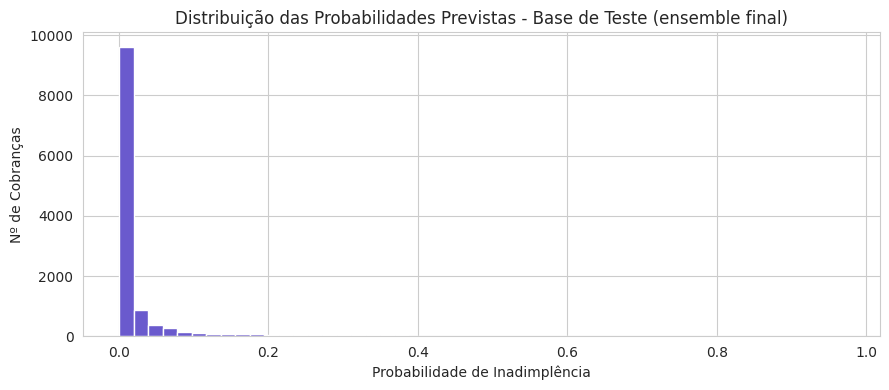

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(proba_teste, bins=50, color='slateblue', edgecolor='white')
ax.set_title('Distribuição das Probabilidades Previstas - Base de Teste (ensemble final)')
ax.set_xlabel('Probabilidade de Inadimplência')
ax.set_ylabel('Nº de Cobranças')
plt.tight_layout()
plt.show()


## 13. Exportação do `submissao_case.csv`

O enunciado pede um `.csv` contendo **exatamente** três colunas:
`ID_CLIENTE`, `SAFRA_REF` e `PROBABILIDADE_INADIMPLENCIA`, nem mais nem
menos. Construo o arquivo de saída partindo só dessas duas colunas de
identificação da base de teste original, e não do `X_test` usado para
prever (que tem várias colunas de atributos) -- assim não corro o risco de
vazar alguma coluna de feature para o arquivo final por descuido. O
`assert` logo abaixo confere isso de forma explícita antes de salvar,
em vez de eu confiar só na leitura visual do código.


In [ ]:
submissao = teste[['ID_CLIENTE', 'SAFRA_REF']].copy()
submissao['PROBABILIDADE_INADIMPLENCIA'] = proba_teste

# validações de formato antes de salvar
assert list(submissao.columns) == ['ID_CLIENTE', 'SAFRA_REF', 'PROBABILIDADE_INADIMPLENCIA']
assert len(submissao) == len(df_teste), "nº de linhas deve bater com base_pagamentos_teste.csv"
assert submissao['PROBABILIDADE_INADIMPLENCIA'].between(0, 1).all(), "probabilidades devem estar entre 0 e 1"
assert submissao['PROBABILIDADE_INADIMPLENCIA'].isna().sum() == 0, "não pode haver probabilidade nula"

submissao.to_csv('submissao_case.csv', index=False)
print("submissao_case.csv salvo com", len(submissao), "linhas.")
submissao.head(10)


submissao_case.csv salvo com 12275 linhas.


,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.003975
1,274692171162531764,2021-07,0.002981
2,274692171162531764,2021-07,0.003420
3,274692171162531764,2021-07,0.003861
4,465309249432033993,2021-07,0.003398
5,465309249432033993,2021-07,0.004137
6,465309249432033993,2021-07,0.004561
7,465309249432033993,2021-07,0.004569
8,5883155883105348987,2021-07,0.006817
9,5883155883105348987,2021-07,0.007685


## 14. Relatório Final -- Conclusões e Recomendações Estratégicas

### Conclusões

O modelo final é um **ensemble por média simples de três bibliotecas de
boosting** (`HistGradientBoostingClassifier`, XGBoost e CatBoost, Seção 9),
escolhido depois de testar de forma exaustiva todas as combinações possíveis
das quatro bibliotecas comparadas e confirmar, fora da amostra usada para
ajustar qualquer coisa, que esse trio empata no AUC-ROC com o conjunto
completo de quatro bibliotecas e tem o melhor KS entre todas as combinações
testadas (AUC-ROC ≈ 0.959, KS ≈ 0.82 em validação fora do tempo). O modelo discrimina
bem clientes com alto e baixo risco de inadimplência e gera probabilidades
bem calibradas, ou seja, "70% de probabilidade" realmente corresponde, na
prática, a algo em torno de 70% de chance real de atraso, não apenas a um
ranking relativo.

A camada de interpretação estatística (Seção 11) confirma, com significância
estatística, que o **comportamento de pagamento passado** (última cobrança,
taxa histórica de inadimplência) é o fator dominante de risco, muito mais do
que atributos cadastrais estáticos como porte ou segmento. Isso tem uma
implicação prática direta: o primeiro atraso de um cliente é o momento mais
importante para agir.

Ao longo do caminho, algumas investigações mudaram decisões que
inicialmente pareciam boas ideias, ou as validaram empiricamente em vez de
simplesmente assumi-las:
- A comparação entre bibliotecas de boosting só ficou confiável depois de
  eu encontrar e corrigir um **bug de ordenação de colunas** entre treino e
  teste (Seção 9.5), um lembrete de que concordância entre modelos
  independentes é uma checagem de sanidade poderosa.
- Testar **todas as combinações possíveis** das quatro bibliotecas (Seção
  9.6.1), e não só a combinação de todas juntas, mudou minha decisão final:
  o ganho do conjunto completo sobre um trio bem escolhido era tão pequeno
  que não justificava manter o modelo a mais. Tirar o LightGBM do ensemble
  final e ficar só com HGB, XGBoost e CatBoost resultou num modelo mais
  simples, com AUC praticamente idêntico e o melhor KS de toda a
  comparação.
- A hipótese de criar um **submodelo dedicado para clientes cold-start** não
  se sustentou empiricamente (Seção 10): com pouco mais de mil exemplos
  disponíveis, o submodelo generalizou pior do que o modelo único treinado
  com toda a base.
- Ao revisar o pipeline com mais um olhar crítico, adicionei uma tolerância
  máxima de 180 dias no join "as of" com `base_info` (Seção 5.3), um
  indicador explícito de cliente novo (`CLIENTE_NOVO`, Seção 5.5) e duas
  features de recência que olham só para as últimas 3 cobranças de cada
  cliente (Seção 5.1), em vez de depender só de agregados sobre o histórico
  inteiro.

### Da probabilidade à ação: réguas de risco

Uma probabilidade sozinha não muda o comportamento de ninguém. Para virar
ação de negócio, sugiro traduzir a saída do modelo em faixas de risco, cada
uma com uma ação de custo proporcional ao risco:

- **Risco alto (> 70%)**: contato humano preventivo antes do vencimento
  (telefone), com abertura para negociar prazo ou condição de pagamento.
- **Risco médio (30% a 70%)**: ação automatizada de baixo custo, SMS ou
  e-mail de lembrete alguns dias antes do vencimento.
- **Risco baixo (< 30%)**: nenhuma ação adicional. Deixar o fluxo normal
  seguir, sem gastar esforço operacional onde ele não é necessário.

Os cortes de 30% e 70% acima são um ponto de partida razoável dada a
distribuição de probabilidades que observei na base de teste (Seção 12), mas
o ideal é calibrá-los observando a capacidade operacional real do time de
cobrança (quantos contatos humanos ele consegue fazer por dia) em vez de
fixar um número arbitrário aqui no notebook.

Também vale aproveitar a camada de interpretação da Seção 11 na ponta da
linha: se o operador de cobrança souber que um cliente está em risco alto
*por causa de* um aumento recente na taxa de atraso, e não por um evento
isolado de anos atrás, a conversa fica mais direcionada e menos genérica.

### Considerações de deploy

O case descreve um sistema que roda **periodicamente**, recebendo novos
dados todo mês, não uma API que responde em tempo real. Isso simplifica a
arquitetura de deploy: não preciso de um serviço síncrono, um pipeline em
lote (*batch*) mensal já atende bem o caso de uso, orquestrado por uma
ferramenta como Airflow, por exemplo, executando na sequência: extração dos
dados mais recentes, aplicação da engenharia de atributos respeitando a
disciplina de "ponto no tempo" da Seção 5, e geração do arquivo de escoragem
para a equipe de cobrança.

O `requirements.txt` que entrego junto com este notebook já é o primeiro
passo para isso: com as versões das bibliotecas fixadas, dá para
encapsular o ambiente em um contêiner (Docker, por exemplo) e evitar o
problema clássico de "na minha máquina funciona" na hora de colocar em
produção.

E como já vimos que o cenário econômico muda ao longo do tempo (a pandemia
mexeu bastante na taxa de inadimplência, Seção 3.5), recomendo monitorar o
modelo depois que ele for para produção, acompanhando tanto mudança no
perfil dos clientes que chegam (*data drift*) quanto mudança no padrão de
inadimplência em si (*concept drift*), para saber quando ele precisa ser
retreinado antes que a performance caia visivelmente.

### Métricas de negócio para acompanhar depois do deploy

Acurácia e AUC são métricas que fazem sentido para mim enquanto construo o
modelo, mas quem vai decidir se ele está realmente ajudando o negócio
provavelmente vai olhar para outra coisa. Separei em duas partes: o que
medir, e como medir de um jeito que realmente prove que foi o modelo (e não
a economia) que causou a melhora.

**O que medir:**
- **Variação da taxa de inadimplência global**: a métrica mais direta de
  sucesso é acompanhar se a taxa de inadimplência da carteira (que gira em
  torno de 7% fora do período de pandemia, Seção 3.5) cai depois de meses
  usando o modelo.
- **Taxa de conversão da régua de cobrança**: dos clientes classificados
  como risco alto e efetivamente contatados, quantos pagaram antes de
  completar os 5 dias de atraso da regra de negócio (Seção 1.3)?
- **Custo evitado vs. custo da ação**: o valor recuperado por avisos
  proativos (clientes de risco que pagaram depois do contato), comparado ao
  custo de fazer esse contato (hora de operador, custo de SMS etc.).
- **Taxa de falso alarme**: quantos clientes marcados como risco alto
  pagariam normalmente mesmo sem nenhum aviso? Ligar sem necessidade para
  um bom cliente cobrando antes do vencimento pode gerar atrito, então vale
  acompanhar esse número junto com a área de experiência do cliente.

**Como medir sem se enganar:** taxa de inadimplência pode cair por outros
motivos além do modelo (a economia melhorar, por exemplo), então, para
isolar o efeito do modelo, sugiro um teste com grupo de controle: aplicar a
régua de cobrança em, digamos, 90% dos clientes classificados como alto
risco (grupo de tratamento) e deixar os outros 10% seguirem o fluxo normal,
sem aviso proativo (grupo de controle/*holdout*). Se a inadimplência do
grupo de tratamento for consistentemente menor que a do grupo de controle,
isso é evidência de que o ganho veio da ação apoiada pelo modelo, e não só
de uma mudança externa que teria acontecido de qualquer jeito.


### Simulação ilustrativa de impacto financeiro

Para sair do abstrato, montei uma simulação simples de quanto essa régua de
risco poderia valer em reais, usando a previsão do próprio ensemble final
no período de validação. Preciso ser bem direto sobre uma coisa antes de
mostrar o número: **os custos abaixo são hipotéticos**, escolhidos só para
ilustrar o método de cálculo, não são dados reais de custo de operação ou
de perda da Datarisk (não tenho acesso a isso, e não deveria supor que
tenho). O valor final não deve ser lido como "quanto a empresa vai
economizar de verdade", e sim como um framework pronto: quando os custos
reais estiverem disponíveis, é só trocar as quatro premissas abaixo pelos
números certos.

Premissas hipotéticas que usei:
- **Custo de um calote**: R$ 500 por cobrança que vira inadimplência (um
  número simplificado, só para ilustrar a conta).

- **Custo de uma ligação preventiva**: R$ 15 por contato.

- **Taxa de sucesso da ligação**: 30% dos clientes de risco que recebem o
  contato acabam pagando em dia mesmo assim.
  
- **Ponto de corte**: ligo só para quem o modelo aponta com probabilidade
  ≥ 70% (a faixa de "risco alto" definida acima).


In [ ]:
# ATENÇÃO: os valores abaixo são hipotéticos, escolhidos só para ilustrar o
# método de cálculo. Não são custos reais da Datarisk.
custo_calote = 500     # R$ perdidos por cobrança que vira inadimplência
custo_ligacao = 15      # R$ gastos por contato preventivo
taxa_sucesso = 0.30     # % dos contatados que pagam em dia mesmo assim
ponto_corte = 0.70      # liga só para quem tem probabilidade >= 70%

# uso a previsão do ensemble final (HGB + XGBoost + CatBoost, Seção 9.7)
# no período de validação, não um dos modelos isolados
proba_ensemble_val = P_val_base[['HGB', 'XGBoost', 'CatBoost']].mean(axis=1)

sim_df = pd.DataFrame({'y_true': y_val.values, 'prob': proba_ensemble_val.values})
sim_df['acao_ligar'] = (sim_df['prob'] >= ponto_corte).astype(int)

# Cenário 1: sem o modelo, ninguém recebe contato preventivo
custo_sem_modelo = sim_df['y_true'].sum() * custo_calote

# Cenário 2: com o modelo, ligo para quem ele aponta como risco alto
total_ligacoes = sim_df['acao_ligar'].sum()
custo_das_ligacoes = total_ligacoes * custo_ligacao
verdadeiros_positivos = ((sim_df['acao_ligar'] == 1) & (sim_df['y_true'] == 1)).sum()
calotes_evitados = verdadeiros_positivos * taxa_sucesso
economia_com_calotes_evitados = calotes_evitados * custo_calote
custo_com_modelo = custo_sem_modelo - economia_com_calotes_evitados + custo_das_ligacoes

lucro_estimado = custo_sem_modelo - custo_com_modelo

print("----- SIMULAÇÃO ILUSTRATIVA, BASE DE VALIDAÇÃO -----")
print(f"Total de cobranças em validação: {len(sim_df)}")
print(f"Ligações feitas (probabilidade >= {ponto_corte:.0%}): {total_ligacoes}")
print(f"Calotes evitados (estimado): {calotes_evitados:.1f}")
print(f"Custo sem o modelo: R$ {custo_sem_modelo:,.2f}")
print(f"Custo com o modelo: R$ {custo_com_modelo:,.2f}")
print(f"Economia estimada:  R$ {lucro_estimado:,.2f}")


----- SIMULAÇÃO ILUSTRATIVA, BASE DE VALIDAÇÃO -----
Total de cobranças em validação: 11874
Ligações feitas (probabilidade >= 70%): 341
Calotes evitados (estimado): 87.3
Custo sem o modelo: R$ 371,000.00
Custo com o modelo: R$ 332,465.00
Economia estimada:  R$ 38,535.00


In [ ]:
# Antes de confiar nesse número, testo o quanto ele depende das premissas
# que inventei. Se o resultado só for positivo para uma combinação muito
# específica de taxa de sucesso e ponto de corte, isso é um sinal de que o
# framework é frágil, não de que o modelo gera valor.
linhas = []
for corte in [0.5, 0.6, 0.7, 0.8]:
    for sucesso in [0.15, 0.30, 0.45]:
        acao = (proba_ensemble_val >= corte).astype(int)
        vp = ((acao == 1) & (sim_df['y_true'] == 1)).sum()
        evitados = vp * sucesso
        economia = evitados * custo_calote
        custo_lig = acao.sum() * custo_ligacao
        lucro = economia - custo_lig
        linhas.append({'ponto_corte': corte, 'taxa_sucesso': sucesso, 'lucro_estimado': lucro})

sensibilidade = pd.DataFrame(linhas).pivot(index='ponto_corte', columns='taxa_sucesso', values='lucro_estimado')
sensibilidade.round(0)


taxa_sucesso,0.15,0.30,0.45
ponto_corte,,,
0.5,24540.0,57540.0,90540.0
0.6,21450.0,49800.0,78150.0
0.7,16710.0,38535.0,60360.0
0.8,10110.0,23085.0,36060.0


O resultado positivo se mantém em toda a grade de premissas que testei, do cenário mais conservador (corte de 80%, taxa de sucesso de 15%, economia de R\$ 10 mil) ao mais otimista (corte de 50%, taxa de sucesso de 45%, economia de R\$ 90 mil). Isso me dá mais confiança de que a conclusão qualitativa (vale a pena ligar preventivamente para quem o modelo aponta como risco alto) não depende de eu ter acertado o valor exato de R\$ 500 ou de 30%, ela se sustenta numa faixa ampla de cenários, mesmo nos mais pessimistas que testei.

Dito isso, repito o limite principal desta simulação: ela usa números hipotéticos, não custos reais informados pela Datarisk. Antes de qualquer decisão de negócio real, o próximo passo seria substituir essas quatro premissas por números de verdade (custo médio de um calote na carteira, custo real de uma ligação do time de cobrança, taxa de sucesso observada em campanhas anteriores) e rodar essa mesma conta de novo.


### Recomendações Acionáveis

**1. Priorizar cobrança preventiva logo após o 1º atraso**
- Por quê: clientes cuja última cobrança atrasou têm ≈3x mais chance de
  atrasar de novo, e um padrão recente ruim (últimas 3 cobranças) pesa
  ainda mais do que isso (Seção 11).
- Ação: disparar régua de cobrança mais intensa (contato antecipado,
  lembrete antes do vencimento) assim que o cliente registrar o primeiro
  atraso.

**2. Tratamento diferenciado para clientes novos (cold-start)**
- Por quê: ~230 cobranças de teste (≈2%) pertencem a clientes sem nenhum
  histórico prévio, e a ausência de histórico está associada a maior risco
  (Seções 10 e 11). O modelo único já lida bem com isso, não é necessário
  um submodelo separado.
- Ação: usar a própria probabilidade do modelo para calibrar limites de
  crédito mais conservadores nesse público, sem necessidade de um processo
  à parte.

**3. Adotar réguas de risco em vez de um corte único**
- Por quê: o modelo entrega probabilidade contínua e bem calibrada, não
  apenas "vai atrasar / não vai atrasar".
- Ação: segmentar clientes em faixas de risco (alto/médio/baixo) com ações
  de custo proporcional, como detalhado acima.

**4. Monitorar mudanças de regime econômico**
- Por quê: a taxa de inadimplência mensal saltou de ~6% para ~16% no
  início da pandemia (Seção 3.5), evidenciando sensibilidade a choques
  macroeconômicos.
- Ação: acompanhar a taxa de inadimplência mensal da carteira como
  indicador de alerta precoce, e revalidar/recalibrar o modelo quando
  houver desvio relevante frente ao esperado.

**5. Reavaliar o modelo periodicamente**
- Por quê: o sistema roda mês a mês, recebendo novos dados de pagamento
  confirmado.
- Ação: retreinar o modelo periodicamente incorporando as safras mais
  recentes já com pagamento observado, mantendo a mesma disciplina de
  validação fora do tempo usada aqui.

**6. Testes de integridade de dados como rotina, não exceção**
- Por quê: o bug de ordenação de colunas (Seção 9.5) só foi pego por
  acaso, comparando dois modelos entre si.
- Ação: automatizar checagens (schema, ordem de colunas, ranges esperados)
  como parte do pipeline de escoragem mensal.

**7. Monitorar o custo operacional do ensemble**
- Por quê: manter e escorar três modelos custa mais (tempo de treino,
  dependências, manutenção) do que um só.
- Ação: reavaliar periodicamente se o ganho de performance do ensemble
  ainda compensa esse custo frente a alternativas mais simples.

**8. Provar o impacto com um grupo de controle**
- Por quê: taxa de inadimplência pode cair por fatores externos ao modelo.
- Ação: rodar um teste com *holdout* (ex.: 90% tratamento / 10% controle)
  antes de assumir que a queda na inadimplência foi mérito do modelo.

### Próximos Passos e Oportunidades de Evolução

- **Evolução do Ensemble:** O ensemble atual utiliza uma média simples. Com uma base de validação maior, seria possível explorar técnicas avançadas (como *Stacking*) ou atribuir pesos dinâmicos que variem por segmento de cliente.

- **Acompanhamento do *Cold-Start*:** Reavaliar o segmento sem histórico à medida que novos dados forem acumulados, visto que a conclusão atual (Seção 10) pode se alterar com o aumento da volumetria de clientes novos.

- **Implementação de MLOps:** Formalizar o processo de monitoramento de *data drift* e *concept drift* descrito nas recomendações, evoluindo de uma análise ad-hoc para um pipeline automatizado.

- **Rollout e Mensuração:** Construir os dashboards de acompanhamento das métricas de negócio e estruturar formalmente o teste A/B (grupo de controle) antes de escalar o modelo para 100% da operação.


## 15. Fontes e Referências

Ao longo do desenvolvimento, pesquisei documentação oficial e material de
referência para apoiar algumas das decisões técnicas deste notebook. Deixo
registrado aqui, como sugerido no enunciado do case:

- **`HistGradientBoostingClassifier` (scikit-learn)**, documentação oficial
  sobre o parâmetro `categorical_features='from_dtype'` e o tratamento
  nativo de valores ausentes:
  <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html>
- **`pandas.merge_asof`**, documentação oficial, incluindo o parâmetro
  `tolerance` usado na Seção 5.3:
  <https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html>
- **Vazamento de dados (*data leakage*) em atributos derivados de séries
  temporais**, sobre por que agregados de histórico precisam respeitar a
  ordem cronológica dos eventos:
  <https://towardsdatascience.com/seven-common-causes-of-data-leakage-in-machine-learning-75f8a6243ea5/>
- **Estatística KS (Kolmogorov-Smirnov) em modelos de crédito**, sobre o
  motivo de ser uma métrica tradicional nesse tipo de problema:
  <https://towardsdatascience.com/kolmogorov-smirnov-statistic-explained-measuring-model-power-in-credit-risk-modeling/>
- **Ensembles por média simples vs. *stacking***, sobre por que a média
  simples costuma capturar boa parte do ganho de combinar modelos:
  <https://machinelearningmastery.com/essence-of-stacking-ensembles-for-machine-learning/>
- **Interpretação de *odds ratio* em regressão logística**, base para a
  leitura da Seção 11:
  <https://stats.oarc.ucla.edu/other/mult-pkg/faq/general/faq-how-do-i-interpret-odds-ratios-in-logistic-regression/>
- **O bug de ordenação de colunas da Seção 9.5**: encontrei um relato
  independente do mesmo comportamento no LightGBM (previsões diferentes
  conforme a ordem das colunas do `DataFrame`, mesmo com os nomes
  corretos), o que me deu mais confiança de que não era um problema
  isolado do meu ambiente:
  <https://mljar.com/blog/lightgbm-predict-column-order-issue/>. A
  discussão que confirma o comportamento equivalente (e a correção) no
  scikit-learn está em
  <https://github.com/scikit-learn/scikit-learn/issues/12936>.

Também usei a documentação oficial do LightGBM, XGBoost e CatBoost para
configurar o suporte nativo a colunas categóricas de cada biblioteca
(parâmetro `categorical_feature` no LightGBM, `enable_categorical` no
XGBoost, e `cat_features` no CatBoost), mas não achei necessário listar
cada uma individualmente aqui, já que o uso é direto e está comentado no
próprio código das Seções 9 e 12.


### Referências Fundamentais e Metodologia

Além da documentação técnica consultada para a execução pontual do código, a estruturação deste case reflete a base metodológica que utilizo para pensar em Ciência de Dados. Os seguintes materiais moldaram a forma como abordei este problema:

- Chip Huyen, **Projetando Sistemas de Machine Learning** (O'Reilly / Alta Books): Esta obra é a base da minha visão sistêmica. Ela fundamenta a ideia de que um modelo não acaba em uma boa métrica de validação, mas sim na sua integração a um produto de dados. Essa linha de pensamento guiou diretamente a construção da Seção 14, onde abordo estratégias de deploy em lote, monitoramento de drift e métricas de negócio.

- Aurélien Géron, **Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow** (O'Reilly / Alta Books): Minha principal referência de engenharia de features e modelagem no dia a dia. A escolha por encapsular o pré-processamento em Pipelines organizados e a disciplina na comparação e validação de modelos foram heranças diretas das melhores práticas deste livro.

- **Data Science Academy** (Fundamentos de Linguagem Python): Além de ter sido minha porta de entrada no ecossistema Python para dados, este material me ensinou a importância da comunicação e do storytelling. O formato escolhido para este notebook intercalando código limpo com justificativas de negócio detalhadas em blocos Markdown foi diretamente inspirado nas práticas ensinadas pela DSA.
